# Deep Learning

José Sousa 11/04/2026

## Dependencies

In [974]:
import os
import random
import json
import time
import gc
import pathlib
import psutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import keras_tuner as kt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import AutoModel, AutoImageProcessor
from tqdm import tqdm

# Fixed seed for reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Directory to save trained models and histories
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)


## Auxiliary Functions

In [975]:
def count_n_images_iterator(this_iterator, name, what='images'):
    """
    Function to count the number of items (images/batches) in the dataset that
    is an iterator. Does not return. Prints a string.

    Input:
        this_iterator: tf.data.Dataset
            Iterator containing the data. TensorFlow Dataset.
        name: str
            Name of the dataset. Should be 'train','test','validation'
        what: str
            Specifies if we are dealing with single images or batches. Should
            be 'images' or 'batches'.

    Output:
        None
    """

    count_items = 0
    for item, label in this_iterator:
        count_items += 1

    print(f'The {name} dataset has {count_items} {what}.')

In [976]:
def plot_acuracy_loss(history, title=None):
    """
    Adapted from: https://www.tensorflow.org/tutorials/images/classification
    """
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(len(acc))  # use actual history length, not global epochs

    fig = plt.figure(figsize=(8, 8))
    if title:
        fig.suptitle(title, fontsize=14, fontweight="bold")

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.legend(loc="lower right")
    plt.title("Training and Validation Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.legend(loc="upper right")
    plt.title("Training and Validation Loss")
    plt.tight_layout()
    plt.show()

# 1. Problem Definition and Data Collection

## What problem are we solving?

For this final assignment, there was a multitude of dataset options for supervised image classification, but i wanted to work on something challenging, that could have real world impact, and that would allow me to develop the basic skills in Deep learning. I ended up converging to a **Multi-class Medical image classification**.

The goal is to train Convolutional Neural Networks (CNN) that, given a chest X-ray image, automatically identify the patient's condition among 4 possible classes:

| Class | Description |
|---|---|
| **Normal** | Healthy cleear lungs with no abnormalities, opacities or visible infiltrates. |
| **Lung Opacity** | A non-specific radiological finding where areas of the lung appear denser than normal. Caused by a range of conditions, such as bacterial pneumonia, pulmonary oedema, or heart failure, but not COVID-19 or viral pneumonia. |
| **COVID-19** | Lung infection caused by the SARS-CoV-2 virus. Typically shows bilateral ground-glass opacities, often in the periphery of the lungs. Visually similar to Lung Opacity, making classification challenging. |
| **Viral Pneumonia** | Lung infection caused by other viruses. Shows diffuse infiltrates, often with a different distribution pattern than COVID-19. |


## 1.1 Dataset

## What type of data?

- **Type:** Chest X-ray images
- **Format:** PNG, 299×299 pixels, grayscale (1 channel)
- **Source:** [COVID-19 Radiography Database (Kaggle)](https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database/data)
- **Number of images:** 21,165

## 1.2 Dataset Scale

Before training any model, i thought it would be interesting to understand the scale of our problem, as the performance is heavily influeced by the number of images and their resolution: more pixels means more detail, but also higher memory and computational cost.

The table below puts in context our Covid dataset against other image datasets used in our Deep Learning classes:


Total Training Pixels = Number_of_Images × Height × Width × Channels

| Dataset      | Train Images | Image Size | Channels | Pixels per Image | Total Training Pixels |
|--------------|-------------|------------|----------|------------------|-----------------------|
| MNIST        | 60,000      | 28×28      | 1        | 784              | ~47M                  |
| CIFAR-10     | 50,000      | 32×32      | 3        | 3,072            | ~154M                 |
| CIFAR-100    | 50,000      | 32×32      | 3        | 3,072            | ~154M                 |
| COVID-19     | 21,165      | 299×299    | 1        | 89,401           | ~1.9B                 |
| ImageNet     | ~1,280,000  | 224×224    | 3        | 150,528          | ~193B                 |

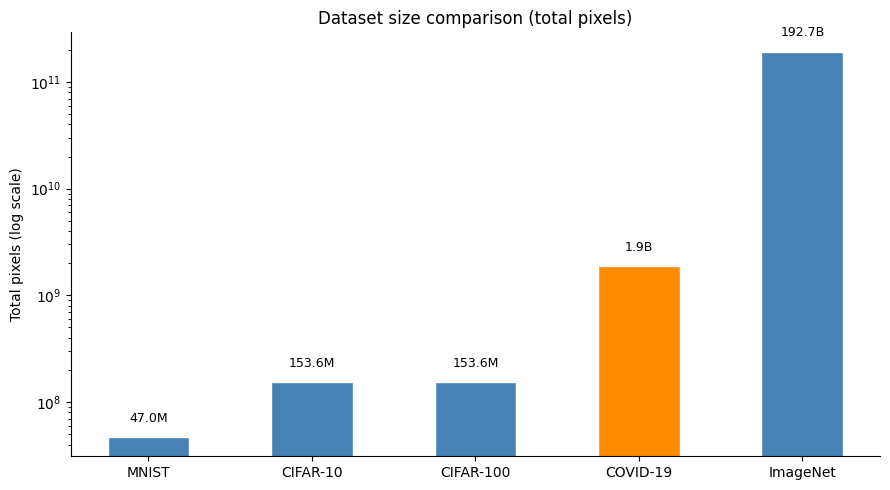

In [977]:
datasets     = ['MNIST', 'CIFAR-10', 'CIFAR-100', 'COVID-19', 'ImageNet']
total_pixels = [
    60_000    * 28  * 28  * 1,   # MNIST
    50_000    * 32  * 32  * 3,   # CIFAR-10
    50_000    * 32  * 32  * 3,   # CIFAR-100
    21_165    * 299 * 299 * 1,   # COVID-19 (ours)
    1_280_000 * 224 * 224 * 3,   # ImageNet
]

colors = ['steelblue', 'steelblue', 'steelblue', 'darkorange', 'steelblue']

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(datasets, total_pixels, color=colors, edgecolor='white', width=0.5)

ax.set_yscale('log')
ax.set_ylabel('Total pixels (log scale)')
ax.set_title('Dataset size comparison (total pixels)')

ax.grid(False)
ax.yaxis.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, total_pixels):
    label = f'{val/1e9:.1f}B' if val >= 1e9 else f'{val/1e6:.1f}M'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
            label, ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 1.3 Model Output

## What will the model output?

For the classification, our model will produce a **vector of 4 probabilities** (one per class) using `softmax` in the final layer. We will use `argmax` on top of that vector, to collapse the probability into a final class prediction.

```
Input:  chest X-ray image (299×299, grayscale)
Output: [P(Normal), P(Lung Opacity), P(COVID-19), P(Viral Pneumonia)]
```


For example: `[0.05, 0.08, 0.82, 0.05]` → predicted class: **COVID-19**


## 1.4 Evaluation Metrics and Target

During training, we will use mainly **Accuracy** as primary metric, since it is simple and fast to compute for each epoch. It is also a good enough training signal and gives an intuitive reading on the learning curve.

For final evaluation, given the class imbalance, we will also check the **confusion matrix** and other important field metrics, particularly for Medical applications, where false negatives might carry high personal and clinical cost! (More detailed discusssion on Metrics is available on chapter 5.1)

| Metric | Why it matters |
|---|---|
| **Recall** | Did we catch all COVID cases? Missing a positive is the highest-stakes error |
| **Precision** | Of those flagged as COVID, how many actually had it? Controls false alarms |
| **F1-score** | A combination of precision and recall, useful when both matter |
| **Confusion matrix** | To show which classes are confused with each other |


### Target

Following my contradictory feelings concerning dataset size, i decided to check some of the top Kaggle contributions to frame my expectations, and define a realistic target: [Other kaggle top contributions](https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database/code?datasetId=576013&sortBy=voteCount)

It is relative easy to find people reporting accuracy scores beetween 92-96% using VGG19 and EfficientNets.

Based on this, i decided to define:
- a minimum  **Target Test Accuracy of 92% accuracy**
- and a **Secondary target of COVID recall above 0.90**


# 2. Load Data

Wanting to benchmark my local hardware for this Deep Learning exercise, I chose to download the dataset and run everything locally rather than on Google Colab.

  Then, proceeded by scanning the folder structure and collect all image file paths and their corresponding class labels.
  
  Each class folder maps to an integer label (0–3), allowing us to inspect the class distribution and identify any imbalances before training.

In [978]:
DATA_DIR = pathlib.Path('.')
IMG_SIZE = 299
BATCH_SIZE     = 32   # default for Baseline + Transfer Learning models
CNN_BATCH_SIZE = 8    # CNN models use Flatten — needs smaller batches at 299x299
SEED = 42

CLASS_NAMES = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

# Collect all image paths and corresponding integer labels
all_paths, all_labels = [], []

for label, class_name in enumerate(CLASS_NAMES):
    images = sorted((DATA_DIR / class_name / 'images').glob('*.png'))
    all_paths.extend([str(p) for p in images])
    all_labels.extend([label] * len(images))

total = len(all_paths)
print(f'Total images: {total}\n')
print(f'{"Class":<25} {"Count":>6}  {"Share":>6}')
print('-' * 40)
for i, name in enumerate(CLASS_NAMES):
    count = all_labels.count(i)
    print(f'{name:<25} {count:>6}  {count/total*100:>5.1f}%')
print('-' * 40)
print(f'{"TOTAL":<25} {total:>6}  100.0%')


Total images: 21165

Class                      Count   Share
----------------------------------------
COVID                       3616   17.1%
Lung_Opacity                6012   28.4%
Normal                     10192   48.2%
Viral Pneumonia             1345    6.4%
----------------------------------------
TOTAL                      21165  100.0%


**Imbalance:** We can already tell that the dataset is inbalaced, as we have almost 8x more Normal images than Viral Pneumonia. If we don't address it properly (class weighting, for example) ithe model will be biased towards the majority class.

Given the limited resources (RAM and GPU memory), it is important to estimate and define appropriate batch size. It controls how many images are loaded into memory at once during training. Large batches train faster and provide smoother results, but require more memory. 

We can estimate the memory footprint of our chosen batch size to confirm the choosen batch size fits safaly within hardware limits:

In [979]:
# Memory footprint per batch
bytes_per_image = IMG_SIZE * IMG_SIZE * 1 * 4  # float32 = 4 bytes
batch_memory_mb = BATCH_SIZE * bytes_per_image / (1024**2)

print(f"Image size       : {IMG_SIZE}x{IMG_SIZE}x1")
print(f"Bytes per image  : {bytes_per_image:,} bytes ({bytes_per_image/1024:.1f} KB)")
print(f"Batch size       : {BATCH_SIZE} images")
print(f"Memory per batch (raw data)       : {batch_memory_mb:.1f} MB")
print(f"Estimated total (x4 for overhead) : {batch_memory_mb*4:.1f} MB  (weights, gradients, optimizer state)")
print()

Image size       : 299x299x1
Bytes per image  : 357,604 bytes (349.2 KB)
Batch size       : 32 images
Memory per batch (raw data)       : 10.9 MB
Estimated total (x4 for overhead) : 43.7 MB  (weights, gradients, optimizer state)



At this point it is worth noting that crashes occurred frequently during development, primarily after migrating from CPU to GPU computation.

Initial training used batches of 128 images processed by 32GB RAM and an Intel Core i7-10850H @ 2.70GHz — functional, but training times regularly exceeded one hour per model.

Migrating to the NVIDIA Quadro RTX 3000 (6GB VRAM) reduced training times dramatically, but the smaller GPU memory required reducing the batch size from 128 to 32 to avoid out-of-memory errors. 

For the CNN models, which use a larger spatial representation, the batch size was further reduced to 8.

In [980]:
ram = psutil.virtual_memory()
print(f'Total RAM : {ram.total / (1024**3):.1f} GB')
print(f'Available : {ram.available / (1024**3):.1f} GB')
print()
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU: {gpus[0].name if gpus else "No GPU detected — training on CPU"}')

Total RAM : 30.9 GB
Available : 9.2 GB

GPU: /physical_device:GPU:0


## 2.1 Sample Image Inspection

Before building the pipeline, it is worth inspecting a sample image to confirm its properties — dimensions, number of channels, data type, and pixel value range. This ensures our loading and preprocessing steps are correctly configured.

Sample class  : COVID
File path     : COVID/images/COVID-1.png
Shape         : (299, 299, 1)         (height x width x channels)
Data type     : <dtype: 'uint8'>
Pixel range   : [0 , 255]
Total pixels  : 89,401


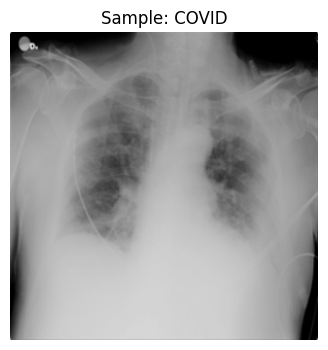

In [981]:
# Load a single sample image to inspect its properties
sample_path = all_paths[0]
sample_class = CLASS_NAMES[all_labels[0]]

raw = tf.io.read_file(sample_path)
image = tf.image.decode_png(raw, channels=1)   # decode as grayscale

print(f'Sample class  : {sample_class}')
print(f'File path     : {sample_path}')
print(f'Shape         : {image.shape}         (height x width x channels)')
print(f'Data type     : {image.dtype}')
print(f'Pixel range   : [{int(tf.reduce_min(image))} , {int(tf.reduce_max(image))}]')
print(f'Total pixels  : {image.shape[0] * image.shape[1] * image.shape[2]:,}')

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(image.numpy().squeeze(), cmap='gray')
plt.title(f'Sample: {sample_class}')
plt.axis('off')
plt.show()

Everything looks as expected, 299x299px with only one channel, but it is worth confirming if that is the case for all images:

In [982]:
# Verify image shapes across the entire dataset
shape_counts = {}
for path in all_paths:
    with Image.open(path) as img:
        shape = (img.height, img.width, len(img.getbands()))
        shape_counts[shape] = shape_counts.get(shape, 0) + 1

print(f'{"Shape":<25} {"Count":>6}  {"Share":>6}')
print('-' * 40)
for shape, count in sorted(shape_counts.items()):
    print(f'{str(shape):<25} {count:>6}  {count/len(all_paths)*100:>5.1f}%')

Shape                      Count   Share
----------------------------------------
(299, 299, 1)              21025   99.3%
(299, 299, 3)                140    0.7%


Surprisingly, a small portion of the dataset seems to have 3 channels, potentially RGB.

## 2.2 Shape Verification

This must be further investigated before proceeding with any modelling, by identifying which samples have 3 channels:

In [983]:
# Find which class the RGB (3-channel) images belong to
rgb_per_class = {name: [] for name in CLASS_NAMES}

for path, label in zip(all_paths, all_labels):
    with Image.open(path) as img:
        if len(img.getbands()) == 3:
            rgb_per_class[CLASS_NAMES[label]].append(path)

print(f'{"Class":<25} {"RGB images":>10}')
print('-' * 37)
for name, paths in rgb_per_class.items():
    print(f'{name:<25} {len(paths):>10}')
    for p in paths[:5]:
        print(f'    {p}')

Class                     RGB images
-------------------------------------
COVID                              0
Lung_Opacity                       0
Normal                             0
Viral Pneumonia                  140
    Viral Pneumonia/images/Viral Pneumonia-1004.png
    Viral Pneumonia/images/Viral Pneumonia-1005.png
    Viral Pneumonia/images/Viral Pneumonia-1017.png
    Viral Pneumonia/images/Viral Pneumonia-1084.png
    Viral Pneumonia/images/Viral Pneumonia-1123.png


## 2.3 Investigating RGB Outliers

The shape check revealed that the 140 images (0.7%) have 3 channels instead of 1, belong to Viral Pneumonia subset.

We can proceed to investigate if it is a real or fake RGB, by inspecting each channel individually:

File        : Viral Pneumonia/images/Viral Pneumonia-1004.png
Mode        : RGB
Shape       : (299, 299, 3)
R channel   : min=0, max=191, mean=119.7
G channel   : min=0, max=191, mean=119.7
B channel   : min=0, max=191, mean=119.7

R==G: True, R==B: True  →  channels are identical (fake RGB)


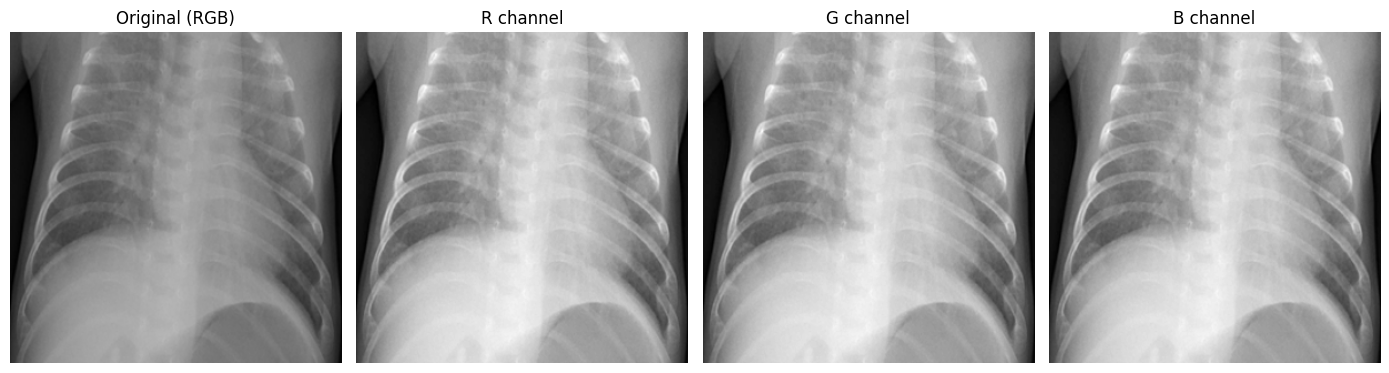

In [984]:
# Inspect one RGB image from Viral Pneumonia

rgb_path = rgb_per_class['Viral Pneumonia'][0]
with Image.open(rgb_path) as img:
    arr = np.array(img)

print(f'File        : {rgb_path}')
print(f'Mode        : {img.mode}')
print(f'Shape       : {arr.shape}')
print(f'R channel   : min={arr[:,:,0].min()}, max={arr[:,:,0].max()}, mean={arr[:,:,0].mean():.1f}')
print(f'G channel   : min={arr[:,:,1].min()}, max={arr[:,:,1].max()}, mean={arr[:,:,1].mean():.1f}')
print(f'B channel   : min={arr[:,:,2].min()}, max={arr[:,:,2].max()}, mean={arr[:,:,2].mean():.1f}')

r_eq_g = np.array_equal(arr[:,:,0], arr[:,:,1])
r_eq_b = np.array_equal(arr[:,:,0], arr[:,:,2])
print(f'\nR==G: {r_eq_g}, R==B: {r_eq_b}  →  {"channels are identical (fake RGB)" if r_eq_g and r_eq_b else "channels differ (true RGB)"}')

# Display all 3 channels side by side
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(arr)
axes[0].set_title('Original (RGB)')
for i, ch in enumerate(['R', 'G', 'B']):
    axes[i+1].imshow(arr[:,:,i], cmap='gray')
    axes[i+1].set_title(f'{ch} channel')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

The statistics reveal that these are fake RGBs, and that all three channels are identical, meaning they are grayscale X-rays stored in an RGB container. 

This is likely an artefact of how those images were originally exported. Since there is no actual colour information, we can convert all images to single-channel grayscale on load, regardless of the source format.

## 2.4 Visual Exploration

To build some intuition on the problem in hands, we can display a sample of images from each class:

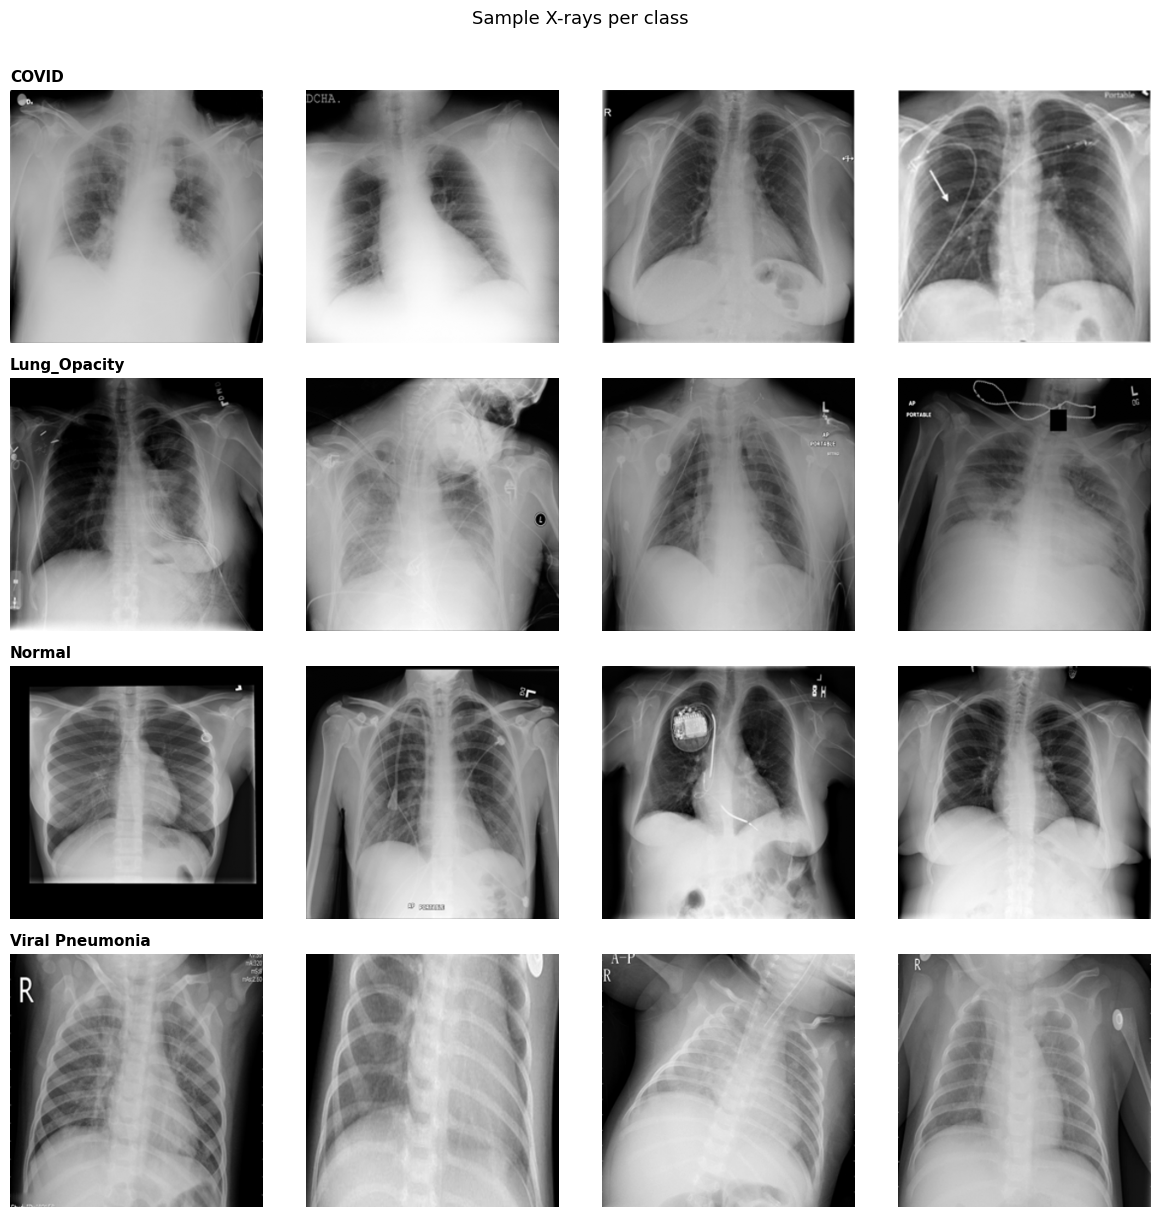

In [985]:
SAMPLES_PER_CLASS = 4

fig, axes = plt.subplots(len(CLASS_NAMES), SAMPLES_PER_CLASS, figsize=(SAMPLES_PER_CLASS * 3, len(CLASS_NAMES) * 3))

for row, (label, class_name) in enumerate(enumerate(CLASS_NAMES)):
    # Get paths for this class and pick evenly spaced samples
    class_paths = [p for p, l in zip(all_paths, all_labels) if l == label]
    indices = np.linspace(0, len(class_paths) - 1, SAMPLES_PER_CLASS, dtype=int)
    samples = [class_paths[i] for i in indices]

    for col, path in enumerate(samples):
        raw = tf.io.read_file(path)
        img = tf.image.decode_png(raw, channels=1).numpy().squeeze()

        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(class_name, fontsize=11, fontweight='bold', loc='left')

plt.suptitle('Sample X-rays per class', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

It is impressive how visually similar the X-rays can be across conditions, which explains why automated classification is both useful and challenging.

On the other hand, significant variability across images is also obvious, including different crop levels, brightness, contrast, and the presence of medical annotations and devices.

This variability is realistic, as it reflects real clinical data collected from multiple sources and acquisition settings.

## 2.5 Dataset Splitting

Now that we are sure all images are the same size, we can split the dataset into **train (70%) / validation (15%) / test (15%)** using a **stratified** split. Stratification ensures that the class imbalance is preserved proportionally across all three subsets.

Without it, a random split could underrepresent a minor clasd, like Viral Pneumonia, in one of the splits:
- In the **training set**, the model would see fewer examples of that class, learning its patterns poorly. It may become biased towards predicting the majority class, since that minimizes loss more easily. If Viral Pneumonia drops from 6% to 2%, the model may almost never predict it.
- In the **validation set**, hyperparameter tuning decisions would be made on misleading performance estimates. A model that never predicts Viral Pneumonia might still look decent on accuracy if that class is rare in validation.
- In the **test set**, the final reported performance would not be reliable. We would no longer be able to trust that the numbers represent real-world behaviour.
- More importantly, in the **real world**, missing a COVID-19 or Viral Pneumonia diagnosis (false negative) is dangerous, as a sick patient could be sent home without treatment!

In short, stratification is not a nice-to-have in medical datasets — it directly affects whether our evaluation is trustworthy.

In [986]:
# Stratified split: preserves class distribution in each subset
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=SEED
)
# Result: 70% train / 15% val / 15% test

print(f'{"Split":<8} {"Total":>6}  {"COVID":>6}  {"Lung_Op":>8}  {"Normal":>7}  {"Viral":>6}')
print('-' * 50)
for split_name, labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    n = len(labels)
    counts = [labels.count(i) for i in range(4)]
    print(f'{split_name:<8} {n:>6}  ' + '  '.join(f'{c:>6} ({c/n*100:.0f}%)' for c in counts))

Split     Total   COVID   Lung_Op   Normal   Viral
--------------------------------------------------
Train     14815    2531 (17%)    4208 (28%)    7134 (48%)     942 (6%)
Val        3175     543 (17%)     902 (28%)    1529 (48%)     201 (6%)
Test       3175     542 (17%)     902 (28%)    1529 (48%)     202 (6%)


## 2.6 Building the Data Pipeline

Finally, we can build `tf.data.Dataset` pipelines for each split.

Each image is loaded from disk, decoded as grayscale, and normalized to [0, 1]. 

Images are grouped into batches with the predefined size as earlier descrived, and prefetched so the next batch is prepared in the background while the model trains on the current one.

In [987]:
# Load image from file path, normalize to [0, 1] and keep original size (299x299)
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=1)     # grayscale → shape (299, 299, 1)
    image = tf.cast(image, tf.float32) / 255.0         # normalize pixel values
    return image, label

def make_dataset(paths, labels, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)  # load next batch while GPU processes current
    return ds

ds_train = make_dataset(train_paths, train_labels)
ds_val   = make_dataset(val_paths,   val_labels)
ds_test  = make_dataset(test_paths,  test_labels)

# Smaller-batch datasets for CNN models (Flatten at 299x299 is memory-intensive)
ds_train_cnn = make_dataset(train_paths, train_labels, batch_size=CNN_BATCH_SIZE)
ds_val_cnn   = make_dataset(val_paths,   val_labels,   batch_size=CNN_BATCH_SIZE)
ds_test_cnn  = make_dataset(test_paths,  test_labels,  batch_size=CNN_BATCH_SIZE)

print('Datasets ready.')
print(f'Batch shape (images): {next(iter(ds_train))[0].shape}')  # (32, 299, 299, 1)

Datasets ready.
Batch shape (images): (32, 299, 299, 1)


# 3. Data Transformation / Preprocessing

## 3.1 Class Weights

As observed earlier, the dataset is imbalanced, but stratification only ensures each split reflects the original class distribution, but the imbalance itself remains. If not addressed, the model will naturally favour the majority class.

We can adddress this using **class weights**: each class is assigned a weight inversely proportional to its frequency. During training, mistakes on minority classes are penalised more heavily, encouraging the model to learn all classes equally:

In [988]:
# Compute class weights inversely proportional to class frequency
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights_array))

print(f'{"Class":<25} {"Images":>7}  {"Weight":>8}')
print('-' * 44)
for i, name in enumerate(CLASS_NAMES):
    count = train_labels.count(i)
    print(f'{name:<25} {count:>7}  {class_weights[i]:>8.4f}')

Class                      Images    Weight
--------------------------------------------
COVID                        2531    1.4634
Lung_Opacity                 4208    0.8802
Normal                       7134    0.5192
Viral Pneumonia               942    3.9318


# 4. Modelling

We can now focus on trainning and comparing multiple models with increasing complexity, hopefuly with positive results.

Starting from a simple baseline allows us to measure the contribution of each architectural improvement.

All the models will be trained, validated and tested on the same data, to ensure a direct and fair performance comparison.

## 4.1 Baseline Model

As baseline, we can start with a fully-connected dense network with no convolutional layers.

This establishes our performance floor, which any CNN should outperform it easily, since dense networks treat each pixel independently.

Since they cannot detecte features like edges, shapes or textures, this tells us what we can get with zero spatical understanding:

In [989]:
baseline_model = Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(4, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 89401)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    22,886,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,920,324 (87.43 MB)

 Trainable params: 22,920,324 (87.43 MB)

 Non-trainable params: 0 (0.00 B)

In [990]:
epochs = 20


_model_path   = f"{MODELS_DIR}/baseline.keras"
_history_path = f"{MODELS_DIR}/baseline_history.json"
_meta_path    = f"{MODELS_DIR}/baseline_meta.json"

if os.path.exists(_model_path):
    print("Loading baseline from disk...")
    baseline_model = keras.models.load_model(_model_path)
    with open(_history_path) as f: history_baseline = type("H", (), {"history": json.load(f)})() 
    with open(_meta_path) as f: _meta = json.load(f)
    print(f"Training time: {_meta['train_minutes']:.1f} min | Best val acc: {_meta['best_val_acc']:.4f}")
else:
    print("Training baseline...")
    _t0 = time.time()
    history_baseline = baseline_model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=epochs,
        class_weight=class_weights
    )
    _train_minutes = (time.time() - _t0) / 60
    _best_val_acc  = max(history_baseline.history["val_accuracy"])
    _trainable_p = int(sum(tf.size(w).numpy() for w in baseline_model.trainable_weights))
    _total_p     = int(sum(tf.size(w).numpy() for w in baseline_model.weights))
    print(f"Done in {_train_minutes:.1f} min | Best val acc: {_best_val_acc:.4f}")
    baseline_model.save(_model_path)
    with open(_history_path, "w") as f: json.dump(history_baseline.history, f)
    with open(_meta_path, "w") as f: json.dump({"train_minutes": _train_minutes, "best_val_acc": _best_val_acc, "trainable_params": _trainable_p, "total_params": _total_p}, f)
    print(f"Saved to {_model_path}")


Loading baseline from disk...
Training time: 1.8 min | Best val acc: 0.7767


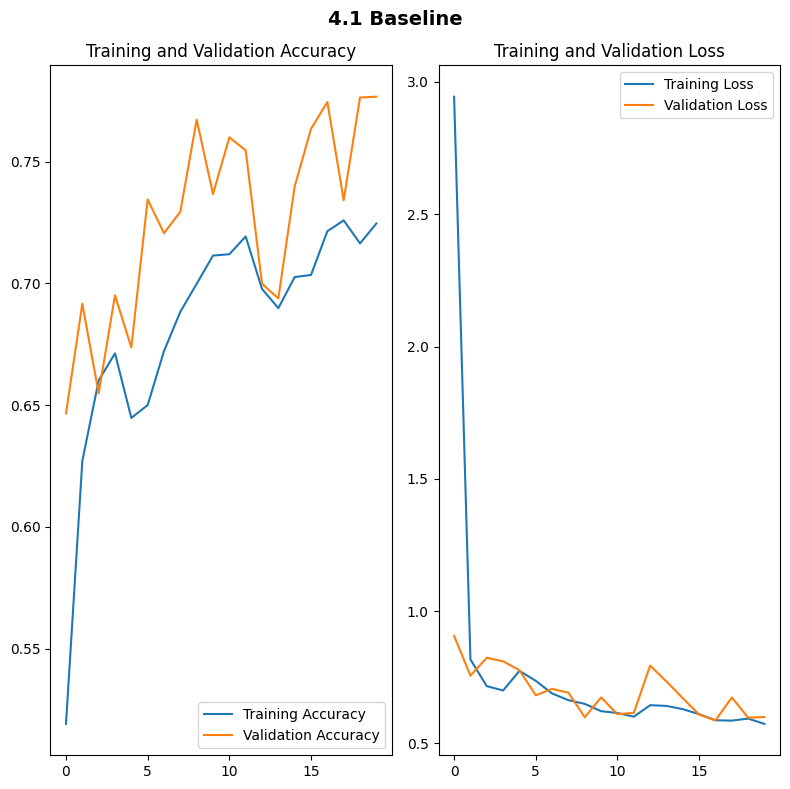

In [991]:
plot_acuracy_loss(history_baseline, title="4.1 Baseline")

## 4.1 Baseline Conclusion

After 20 epochs and **1.8 minutes** of training, it reaches **77.7% validation accuracy**. However, the validation curve oscillates a lot and the model never fully converges.

| Metric | Value |
|---|---|
| **Val accuracy (best)** | 77.7% |
| **Training time** | 1.8 min |
| **Parameters** | ~23M |
| **Overfitting** | Underfitting (val > train throughout)|

Validation accuracy consistently leads training accuracy, a sign that the network lacks the capacity to learn meaningful patterns from the images.

With ~23M parameters concentrated in a single dense layer, most of the weights are spent memorising pixel positions rather than spatial structure.

## 4.2 CNN Model

To address baseline's core limitation, a 3 Convolutional blocks can be added to form our first CNN model.

Instead of treating each pixel independently, three Conv2D blocks with increasing filter depth (32→64→128) learn local filters that detect edges, textures, and shapes at progressively higher levels of abstraction.

The flatten is still there, but now it's flattening learned spatial feature maps, rather than raw pixels!

In [992]:
cnn_model = Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(4, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 299, 299, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 149, 149, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 74, 74, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 175232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │    22,429,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,523,012 (85.92 MB)

 Trainable params: 22,523,012 (85.92 MB)

 Non-trainable params: 0 (0.00 B)

In [993]:
_model_path   = f"{MODELS_DIR}/cnn.keras"
_history_path = f"{MODELS_DIR}/cnn_history.json"
_meta_path    = f"{MODELS_DIR}/cnn_meta.json"

if os.path.exists(_model_path):
    print("Loading cnn from disk...")
    cnn_model = keras.models.load_model(_model_path)
    with open(_history_path) as f: history_cnn = type("H", (), {"history": json.load(f)})() 
    with open(_meta_path) as f: _meta = json.load(f)
    print(f"Training time: {_meta['train_minutes']:.1f} min | Best val acc: {_meta['best_val_acc']:.4f}")
else:
    print("Training cnn...")
    _t0 = time.time()
    history_cnn = cnn_model.fit(
        ds_train_cnn,
        validation_data=ds_val_cnn,
        epochs=15,
        class_weight=class_weights
    )
    _train_minutes = (time.time() - _t0) / 60
    _best_val_acc  = max(history_cnn.history["val_accuracy"])
    _trainable_p = int(sum(tf.size(w).numpy() for w in cnn_model.trainable_weights))
    _total_p     = int(sum(tf.size(w).numpy() for w in cnn_model.weights))
    print(f"Done in {_train_minutes:.1f} min | Best val acc: {_best_val_acc:.4f}")
    cnn_model.save(_model_path)
    with open(_history_path, "w") as f: json.dump(history_cnn.history, f)
    with open(_meta_path, "w") as f: json.dump({"train_minutes": _train_minutes, "best_val_acc": _best_val_acc, "trainable_params": _trainable_p, "total_params": _total_p}, f)
    print(f"Saved to {_model_path}")


Loading cnn from disk...
Training time: 11.4 min | Best val acc: 0.8592


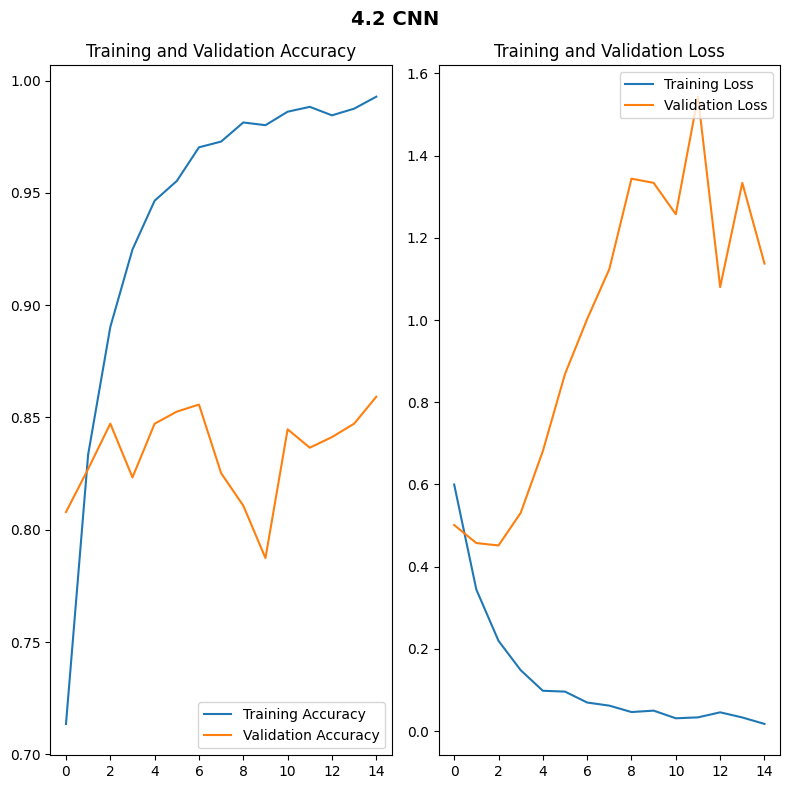

In [994]:
plot_acuracy_loss(history_cnn, title="4.2 CNN")

## 4.2 CNN Conclusion

With the increased spatial awareness, the CNN significantly outperforms the baseline, reaching **85.9% validation accuracy** after **11.4 minutes** of training, a ~8% increase in performance. 

| Metric | Baseline 4.1| CNN 4.2 |
|---|---|---|
| Val accuracy (best) | 78% | **85.9%** |
| Train accuracy (final) | ~73% | ~99% |
| Training time | 1.8 min | 11.4 min |
| Overfitting | Under | **Severe** |

However, the model shows clear **overfitting from epoch 5 onwards**:

- Training accuracy climbs to ~99% while validation plateaus at ~86, a 13% gap
- Validation loss bottoms out early then **rises sharply**, meaning the model gets worse on unseen data despite improving on training data
- In practical terms, training beyond epoch 5 is counterproductive

Conclusion: with 22M parameters, the model has more than enough capacity to memorise the training set, but not generalize from it.

## 4.3 Improved CNN — Dropout + L2

To solve it, we can introduce Regularization to it, through complementary techniques, Dropout and L2, which should close the train/val gap: 

| Technique | Where applied | What it does |
|---|---|---|
| **L2 regularisation** | All Conv2D + Dense(128) | Penalises large weights, pushing the model towards simpler, more general solutions |
| **Dropout(0.5)** | After Dense(128) | Randomly disables 50% of neurons each step, preventing memorisation |

Everything else is identical to 4.2 so the comparison is clean — any accuracy difference can be directly attributable to our regularisation:


In [995]:
cnn_v2_model = Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same",
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same",
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same",
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation="relu",
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

cnn_v2_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_v2_model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 299, 299, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 149, 149, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 74, 74, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 175232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    22,429,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,523,012 (85.92 MB)

 Trainable params: 22,523,012 (85.92 MB)

 Non-trainable params: 0 (0.00 B)

In [996]:
_model_path   = f"{MODELS_DIR}/cnn_v2.keras"
_history_path = f"{MODELS_DIR}/cnn_v2_history.json"
_meta_path    = f"{MODELS_DIR}/cnn_v2_meta.json"

if os.path.exists(_model_path):
    print("Loading cnn_v2 from disk...")
    cnn_v2_model = keras.models.load_model(_model_path)
    with open(_history_path) as f: history_cnn_v2 = type("H", (), {"history": json.load(f)})() 
    with open(_meta_path) as f: _meta = json.load(f)
    print(f"Training time: {_meta['train_minutes']:.1f} min | Best val acc: {_meta['best_val_acc']:.4f}")
else:
    print("Training cnn_v2...")
    _t0 = time.time()
    history_cnn_v2 = cnn_v2_model.fit(
        ds_train_cnn,
        validation_data=ds_val_cnn,
        epochs=40,
        class_weight=class_weights
    )
    _train_minutes = (time.time() - _t0) / 60
    _best_val_acc  = max(history_cnn_v2.history["val_accuracy"])
    _trainable_p = int(sum(tf.size(w).numpy() for w in cnn_v2_model.trainable_weights))
    _total_p     = int(sum(tf.size(w).numpy() for w in cnn_v2_model.weights))
    print(f"Done in {_train_minutes:.1f} min | Best val acc: {_best_val_acc:.4f}")
    cnn_v2_model.save(_model_path)
    with open(_history_path, "w") as f: json.dump(history_cnn_v2.history, f)
    with open(_meta_path, "w") as f: json.dump({"train_minutes": _train_minutes, "best_val_acc": _best_val_acc, "trainable_params": _trainable_p, "total_params": _total_p}, f)
    print(f"Saved to {_model_path}")


Loading cnn_v2 from disk...
Training time: 31.1 min | Best val acc: 0.8706


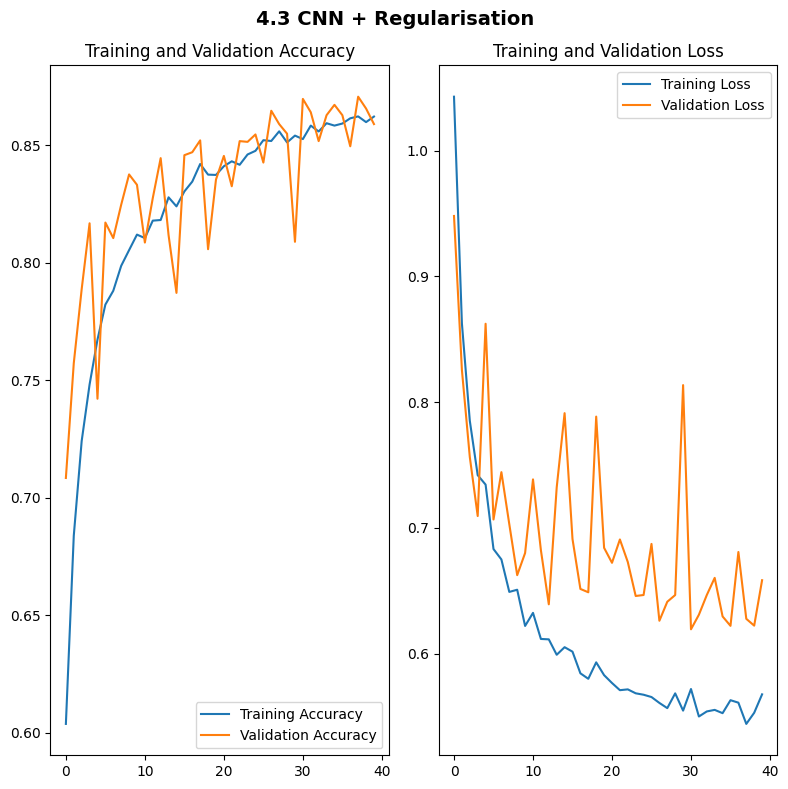

In [997]:
plot_acuracy_loss(history_cnn_v2, title="4.3 CNN + Regularisation")

## 4.3 CNN + Regularisation Conclusion

Adding an agressive Dropout and L2 regularisation strategy **eliminated overfitting**, resulting in **87.1% validation accuracy**, a better result than the unregularised CNN despite being trained on the same data. 

The extended training, up to 40 epochs, took **31.1 minutes**.

| Metric | Baseline 4.1 | CNN 4.2 | CNN + Reg 4.3 |
|---|---|---|---|
| Val accuracy (best) | 78% | 85.9% | **87.1%** |
| Train accuracy (final) | ~73% | ~99% | ~86% |
| Train/val gap | ~5pp | **13pp** | **~0pp** |
| Training time | 1.8 min | 11.4 min | 31.1 min |
| OverFitting | Under | Severe from epoch 5 | **None** |
| Val loss trend | Unstable | Rising after epoch 5 | **Decreasing** |

Key observations:

- **No overfitting**: val stays at or above train
- **Val loss noisy but decreasing**: expected with the small batch size of 8, and Dropout(0.5)
- **99% > 86%**: the drop in training accuracy does not reflect a regression, but the removal of memorisation. The model is now learning generalisable features.

Both models so far were trained from scratch, with every weight initialized randomly and learned solely from our training images.

Rather than continuing to optimise from scratch, the next logical step is transfer learning: bringing in weights already trained on millions of images!

## 4.4 Transfer Learning

Rather than learning from scratch on 15K images, we cam reuse networks pretrained on ImageNet (1.2M images), where low-level features like edges, textures, and shapes are already learned. My cusiosity is on whether these general visual features transfer well to medical X-rays.

Two architectures were selected:

| Model | Params | Why |
|---|---|---|
| **MobileNetV2** | 3.4M | Lightweight, fast, ideal for development and small datasets |
| **EfficientNetB0** | 5.3M | Better accuracy, designed for 224×224, stronger feature extractor |

**Strategy**: freeze the backbone weights and train only a small classification head on top. It should be fast, low risk of overfitting, and no ImageNet knowledge is lost.

As both models expect 3-channel (RGB) input, grayscale images are converted by repeating the single channel 3 times.


### 4.4a MobileNetV2

MobileNetV2 is a lightweight architecture that uses depthwise separable convolutions to achieve competitive accuracy with fewer operations:

https://www.tensorflow.org/api_docs/python/tf/keras/applications/MobileNetV2

https://arxiv.org/abs/1801.04381

Let's freeze its ImageNet backbone and train only a small classification head on top.

In [998]:
mobilenet_base = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
mobilenet_base.trainable = False

mobilenet_model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.Resizing(224, 224),
    layers.Lambda(lambda x: tf.repeat(x, 3, axis=-1)),
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(4, activation="softmax")
])

mobilenet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [999]:
_model_path   = f"{MODELS_DIR}/mobilenet.keras"
_history_path = f"{MODELS_DIR}/mobilenet_history.json"
_meta_path    = f"{MODELS_DIR}/mobilenet_meta.json"

if os.path.exists(_model_path):
    print("Loading mobilenet weights from disk...")
    mobilenet_model.load_weights(_model_path)
    with open(_history_path) as f: history_mobilenet = type("H", (), {"history": json.load(f)})()
    with open(_meta_path) as f: _meta = json.load(f)
    print(f"Training time: {_meta['train_minutes']:.1f} min | Best val acc: {_meta['best_val_acc']:.4f}")
else:
    print("Training mobilenet...")
    _t0 = time.time()
    history_mobilenet = mobilenet_model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=20,
        class_weight=class_weights
    )
    _train_minutes = (time.time() - _t0) / 60
    _best_val_acc  = max(history_mobilenet.history["val_accuracy"])
    _trainable_p = int(sum(tf.size(w).numpy() for w in mobilenet_model.trainable_weights))
    _total_p     = int(sum(tf.size(w).numpy() for w in mobilenet_model.weights))
    print(f"Done in {_train_minutes:.1f} min | Best val acc: {_best_val_acc:.4f}")
    mobilenet_model.save(_model_path)
    with open(_history_path, "w") as f: json.dump(history_mobilenet.history, f)
    with open(_meta_path, "w") as f: json.dump({"train_minutes": _train_minutes, "best_val_acc": _best_val_acc, "trainable_params": _trainable_p, "total_params": _total_p}, f)
    print(f"Saved to {_model_path}")

Loading mobilenet weights from disk...
Training time: 6.8 min | Best val acc: 0.8879


/home/jose-sousa/PG/DL/DeepLearning2026/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


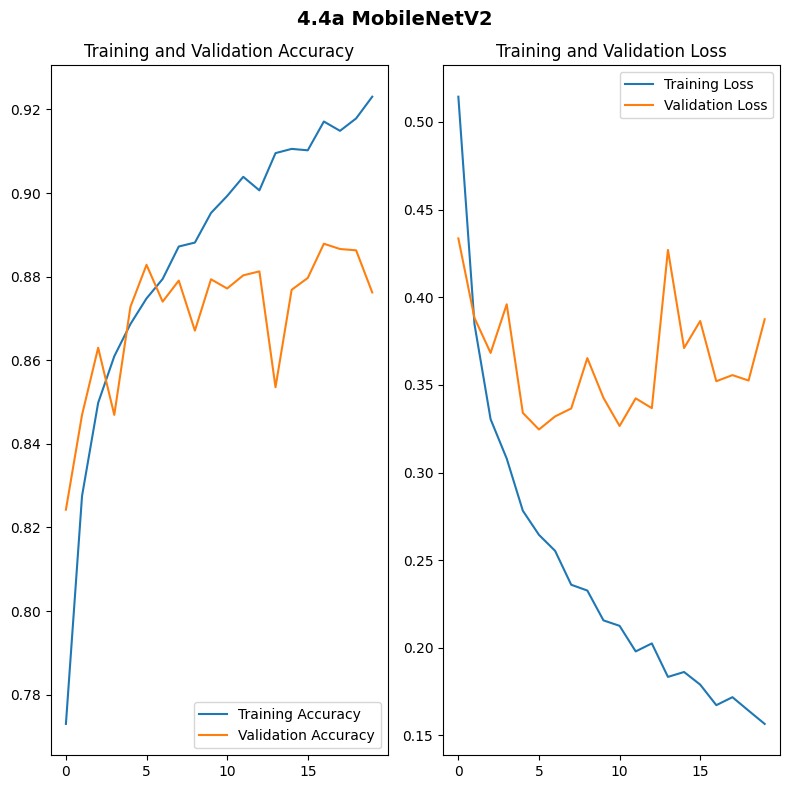

In [1000]:
plot_acuracy_loss(history_mobilenet, title="4.4a MobileNetV2")

### 4.4a MobileNetV2 Conclusion

MobileNetV2 reaches **88.8% validation accuracy** in just **6.8 minutes**, outperforming all scratch-trained models up to now.

| Metric | Baseline 4.1 | CNN 4.2 | CNN+Reg 4.3 | MobileNetV2 4.4a |
|---|---|---|---|---|
| Val accuracy (best) | 78% | 85.9% | 87.1% | **88.8%** |
| Train accuracy (final) | ~73% | ~99% | ~86% | ~93% |
| Train/val gap | ~5pp | 13pp | ~0pp | ~5pp |
| Training time | 1.8 min | 11.4 min | 31.1 min | **6.8 min** |
| Overfitting | Under | Severe | None | Moderate |
| Cold start | Yes | Yes | Yes | **No** |

Key observations:

- **Strong cold start at 82%**: pretrained ImageNet weights are immediately useful
- **4.5× faster than CNN+Reg** with slight better accuracy (frozen backbone eliminates the need to learn low-level features from scratch)
- **Moderate overfitting from ~epoch 8** — training climbs to ~93% while validation plateaus at ~88%, a ~5pp gap. Val loss oscillates but does not diverge.

MobileNetV2 demonstrates the core advantage of transfer learning: faster training and better generalisation by reusing features learned from millions of images.

Adding fine-tuning (unfreezing the top layers of the backbone) would likely push accuracy further, at the cost of longer training, but we are exploring increasing complexity, so the next question is whether EfficientNetB0's stronger backbone can push accuracy further!

### 4.4b EfficientNetB0

EfficientNetB0 uses **compound scaling** (simultaneously scaling network depth, width, and input resolution by a fixed ratio), rather than scaling one dimension alone. 

https://www.tensorflow.org/api_docs/python/tf/keras/applications/EfficientNetB0

https://arxiv.org/abs/1905.11946

This produces a more balanced architecture that generalises better across tasks.

Like MobileNetV2, the backbone is frozen with ImageNet weights and we can add our small trainable head on top:

In [1001]:
efficientnet_base = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
efficientnet_base.trainable = False

efficientnet_model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.Resizing(224, 224),
    layers.Lambda(lambda x: tf.repeat(x, 3, axis=-1)),
    layers.Lambda(lambda x: efficientnet_preprocess(x * 255.0)),
    efficientnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(4, activation="softmax")
])

efficientnet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

efficientnet_model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [1002]:
_model_path   = f"{MODELS_DIR}/efficientnet.keras"
_history_path = f"{MODELS_DIR}/efficientnet_history.json"
_meta_path    = f"{MODELS_DIR}/efficientnet_meta.json"

if os.path.exists(_model_path):
    print("Loading efficientnet weights from disk...")
    efficientnet_model.load_weights(_model_path)
    with open(_history_path) as f: history_efficientnet = type("H", (), {"history": json.load(f)})()
    with open(_meta_path) as f: _meta = json.load(f)
    print(f"Training time: {_meta['train_minutes']:.1f} min | Best val acc: {_meta['best_val_acc']:.4f}")
else:
    print("Training efficientnet...")
    _t0 = time.time()
    history_efficientnet = efficientnet_model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=40,
        class_weight=class_weights
    )
    _train_minutes = (time.time() - _t0) / 60
    _best_val_acc  = max(history_efficientnet.history["val_accuracy"])
    _trainable_p = int(sum(tf.size(w).numpy() for w in efficientnet_model.trainable_weights))
    _total_p     = int(sum(tf.size(w).numpy() for w in efficientnet_model.weights))
    print(f"Done in {_train_minutes:.1f} min | Best val acc: {_best_val_acc:.4f}")
    efficientnet_model.save(_model_path)
    with open(_history_path, "w") as f: json.dump(history_efficientnet.history, f)
    with open(_meta_path, "w") as f: json.dump({"train_minutes": _train_minutes, "best_val_acc": _best_val_acc, "trainable_params": _trainable_p, "total_params": _total_p}, f)
    print(f"Saved to {_model_path}")

Loading efficientnet weights from disk...
Training time: 11.9 min | Best val acc: 0.9235


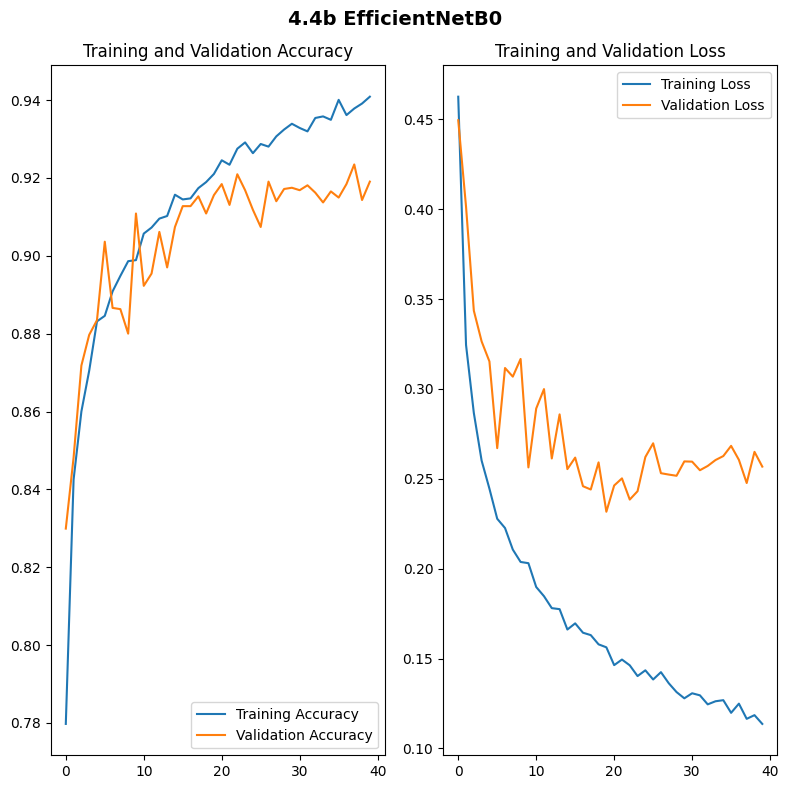

In [1003]:
plot_acuracy_loss(history_efficientnet, title="4.4b EfficientNetB0")

### 4.4b EfficientNetB0 Conclusion

EfficientNetB0 reaches **92.4% validation accuracy** in **11.9 minutes** over 40 epochs! The best result among all models, and 3.6pp above MobileNetV2.

| Metric | Baseline 4.1 | CNN 4.2 | CNN+Reg 4.3 | MobileNetV2 4.4a | EfficientNetB0 4.4b |
|---|---|---|---|---|---|
| Val accuracy (best) | 78% | 85.9% | 87.1% | 88.8% | **92.4%** |
| Train accuracy (final) | ~73% | ~99% | ~86% | ~93% | ~94% |
| Train/val gap | ~5pp | 13pp | ~0pp | ~5pp | **~2pp** |
| Training time | 1.8 min | 11.4 min | 31.1 min | 6.8 min | 11.9 min |
| OverFitting | Under | Severe | None | Moderate | **Minimal** |
| Cold start | Yes | Yes | Yes | No | **No** |

Key observations:

- **Minimal overfitting**: tain and val converge at ~94%/~92%, a negligible 2% gap
- **Near ceiling at 25 epochs**: extending traomomg to 40 epochs yielded only +0.4pp; the frozen backbone is the limiting factor
- **Strong cold start at 83%**: richer ImageNet features than MobileNetV2, immediately effective on chest X-ray patterns.

EfficientNetB0 is the clear winner among ImageNet transfer learning models, but I wonder wether a Domain specific model pretrained speciffically on medical images could go on our X-ray dataset.

## 4.5 Domain-Specific Transfer Learning — RAD-DINO

Both transfer learning models used so far were based on ImageNet dataset (everyday photos). 

On the other hand, **RAD-DINO** is a pre-trained model exclusively on **chest X-rays**, using self-supervised learning (DINO). It has never seen natural images, every feature it learned comes from radiology data, which should bring additional performance on our application.

https://huggingface.co/microsoft/rad-dino

https://arxiv.org/abs/2401.10815

Unlike the CNN-based models used so far, RAD-DINO is a Vision Transformer (ViT).

Instead of learning local filters through convolutions, it divides the image into fixed patches and processes them as a sequence using self-attention, just like LLMs do, allowing each patch to attend to every other part of the image simultaneously.

| Property | MobileNetV2 / EfficientNetB0 | RAD-DINO |
|---|---|---|
| Pre-training data | ImageNet (1.2M photos) | **Chest X-rays only** |
| Architecture | CNN | Vision Transformer (ViT-B/14) |
| Feature size | 1,280 | **768** |
| Domain match | Generic | **Exact domain** |

**Strategy:** RAD-DINO is PyTorch-based. We use it as a **frozen feature extractor**, run all images through it once, save the 768-dim feature vectors, then train a small Keras classifier on those features.


### 4.5.1 Feature Extraction

So, let's run all images through RAD-DINO once and save the 768-dim feature vectors as a one time operation:


In [1004]:
# === RAD-DINO STEP 1: Load Model ===

# Free TensorFlow GPU memory
tf.keras.backend.clear_session()
gc.collect()
torch.cuda.empty_cache()

free_mem = torch.cuda.mem_get_info()[0] / 1024**3
print(f"GPU free after TF clear: {free_mem:.2f} GB")

device = torch.device("cuda" if torch.cuda.is_available() and free_mem > 1.0 else "cpu")
print(f"Using device: {device}")

# Load RAD-DINO
print("Loading RAD-DINO...")
rad_dino = AutoModel.from_pretrained("microsoft/rad-dino")
processor = AutoImageProcessor.from_pretrained("microsoft/rad-dino")
rad_dino = rad_dino.to(device)
rad_dino.eval()
print(f"RAD-DINO on {device}. GPU free: {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB")


GPU free after TF clear: 0.97 GB
Using device: cpu
Loading RAD-DINO...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

RAD-DINO on cpu. GPU free: 0.97 GB


In [1005]:
# === RAD-DINO STEP 2: Extract Features (run AFTER Step 1) ===
FEATURES_DIR = "rad_dino_features"
os.makedirs(FEATURES_DIR, exist_ok=True)

def extract_and_save(paths, labels, split_name, batch_size=8):
    feat_path  = f"{FEATURES_DIR}/{split_name}_features.npy"
    label_path = f"{FEATURES_DIR}/{split_name}_labels.npy"

    if os.path.exists(feat_path):
        print(f"{split_name}: loading from disk...")
        return np.load(feat_path), np.load(label_path)

    print(f"{split_name}: extracting {len(paths)} images on {device}...")
    _t0 = time.time()
    all_features = []
    for i in tqdm(range(0, len(paths), batch_size), desc=split_name):
        batch_paths = paths[i:i + batch_size]
        images = [Image.open(p).convert("RGB") for p in batch_paths]
        inputs = processor(images=images, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = rad_dino(**inputs)
        features = outputs.last_hidden_state[:, 0, :].cpu().float().numpy()
        all_features.append(features)
        torch.cuda.empty_cache()  # free cache after each batch

    features = np.concatenate(all_features, axis=0)
    _elapsed = (time.time() - _t0) / 60
    np.save(feat_path, features)
    np.save(label_path, np.array(labels))
    print(f"  Saved to {feat_path} — shape: {features.shape} — time: {_elapsed:.1f} min")
    return features, np.array(labels)

_total_t0 = time.time()
train_features, train_labels_np = extract_and_save(train_paths, train_labels, "train")
val_features,   val_labels_np   = extract_and_save(val_paths,   val_labels,   "val")
test_features,  test_labels_np  = extract_and_save(test_paths,  test_labels,  "test")
_total_extraction_min = (time.time() - _total_t0) / 60

print(f"Train : {train_features.shape}")
print(f"Val   : {val_features.shape}")
print(f"Test  : {test_features.shape}")
print(f"Total extraction time: {_total_extraction_min:.1f} min")

train: loading from disk...
val: loading from disk...
test: loading from disk...
Train : (14815, 768)
Val   : (3175, 768)
Test  : (3175, 768)
Total extraction time: 0.0 min


### 4.5.2 Train Keras Classifier on RAD-DINO Features

With features extracted and saved, we train a small fully-connected network on top: two Dense layers that map the 768-dimensional RAD-DINO vector to one of the four classes.

All the visual reasoning is already encoded in the features, so our Dense layers only need to learn which combinations correspond to each class:

In [1006]:
# === RAD-DINO STEP 3: Define Classifier ===

rad_dino_model = Sequential([
    layers.Input(shape=(768,)),
    layers.Dense(256, activation="relu",
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

rad_dino_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

rad_dino_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,892 (773.02 KB)

 Trainable params: 197,892 (773.02 KB)

 Non-trainable params: 0 (0.00 B)

In [1007]:
# === RAD-DINO STEP 4: Train (run AFTER Step 2 and 3) ===
_model_path   = f"{MODELS_DIR}/rad_dino.keras"
_history_path = f"{MODELS_DIR}/rad_dino_history.json"
_meta_path    = f"{MODELS_DIR}/rad_dino_meta.json"

if os.path.exists(_model_path):
    print("Loading RAD-DINO classifier from disk...")
    rad_dino_model = keras.models.load_model(_model_path)
    with open(_history_path) as f: history_rad_dino = type("H", (), {"history": json.load(f)})()
    with open(_meta_path) as f: _meta = json.load(f)
    print(f"Training time: {_meta['train_minutes']:.1f} min | Best val acc: {_meta['best_val_acc']:.4f}")
else:
    print("Training RAD-DINO classifier...")
    _t0 = time.time()
    history_rad_dino = rad_dino_model.fit(
        train_features, train_labels_np,
        validation_data=(val_features, val_labels_np),
        epochs=20,
        batch_size=128,
        class_weight=class_weights
    )
    _train_minutes = (time.time() - _t0) / 60
    _best_val_acc  = max(history_rad_dino.history["val_accuracy"])
    _trainable_p = int(sum(tf.size(w).numpy() for w in rad_dino_model.trainable_weights))
    _total_p     = int(sum(tf.size(w).numpy() for w in rad_dino_model.weights))
    print(f"Done in {_train_minutes:.1f} min | Best val acc: {_best_val_acc:.4f}")
    rad_dino_model.save(_model_path)
    with open(_history_path, "w") as f: json.dump(history_rad_dino.history, f)
    with open(_meta_path, "w") as f: json.dump({"train_minutes": _train_minutes, "best_val_acc": _best_val_acc, "trainable_params": _trainable_p, "total_params": _total_p}, f)
    print(f"Saved to {_model_path}")


Loading RAD-DINO classifier from disk...
Training time: 30.8 min | Best val acc: 0.9414


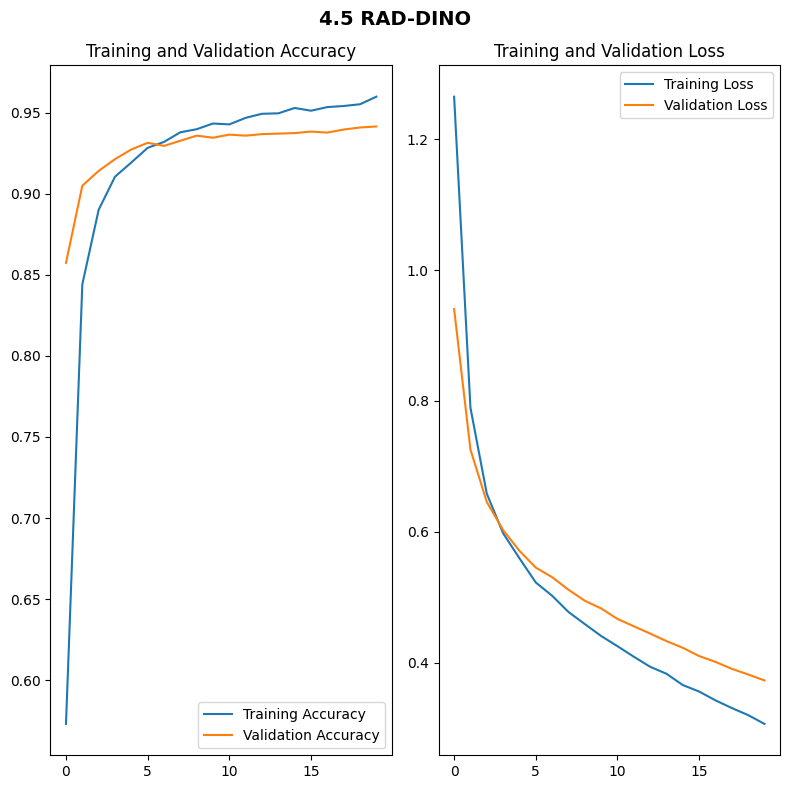

In [1008]:
plot_acuracy_loss(history_rad_dino, title="4.5 RAD-DINO")


### 4.5 RAD-DINO Conclusion

At **94.1% validation accuracy**. RAD-DINO delivers the strongest result of all models. A 1.7% jump over EfficientNetB0 and 16.4% above the baseline.

| Metric | Baseline 4.1 | CNN 4.2 | CNN+Reg 4.3 | MobileNetV2 | EfficientNetB0 | **RAD-DINO** |
|---|---|---|---|---|---|---|
| Val accuracy (best) | 77.7% | 85.9% | 87.1% | 88.8% | 92.4% | **94.1%** |
| Training time | 1.8 min | 11.4 min | 31.1 min | 6.8 min | 11.9 min | **~31 min*** |
| Overfitting | Under | Severe | None | Moderate | Minimal | **None** |
| Cold start (ep.1) | ~58% | ~80% | ~70% | ~83% | ~83% | **~90%** |
| Domain match | No | No | No | No | No | **Yes** |

*~30.7 min feature extraction + 0.2 min classifier training. Feature extraction is a one-time cost, subsequent runs load from disk instantly.

Key observations:

- **Smoothest curves of all models**: train and val track almost identically, with both losses converging together. No sign of overfitting at any point.
- **90% val accuracy from epoch 1**: no cold start. RAD-DINO features already encode the exact visual patterns that distinguish COVID-19, Lung Opacity, Normal, and Viral Pneumonia.
- **0.2 min classifier training**: once features are extracted, training the head is essentially instant. The heavy computing is done once during feature extraction.

**Key insight:** domain-specific pretraining decisively outperforms generic ImageNet transfer learning for medical imaging.

For propper deployment, this model (further fine-tuned with data augmentatio) would be the clear starting point.

## 4.6 Model Comparison

We can now compare all models across three dimensions: **parameter efficiency**, **validation accuracy**, and **training cost**. This highlights the trade-offs between model complexity, domain knowledge, and performance:

| Model | Trainable Params | Frozen Params | Input Size | Epochs | Train Time | Val Acc |
|---|---|---|---|---|---|---|
| Baseline 4.1 | 22.9M | 0 | 299×299 | 20 | 1.8 min | 77.7% |
| CNN 4.2 | 22.5M | 0 | 299×299 | 15 | 11.4 min | 85.9% |
| CNN+Reg 4.3 | 22.5M | 0 | 299×299 | 40 | 31.1 min | 87.1% |
| MobileNetV2 | 164K | 2.3M | 224×224 | 20 | 6.8 min | 88.8% |
| EfficientNetB0 | 164K | 4.1M | 224×224 | 40 | 11.9 min | 92.4% |
| **RAD-DINO** | **198K** | **~86M*** | **518×518** | **20** | **30.8 min** ** | **94.1%** |

*RAD-DINO backbone weights not loaded into Keras — feature extraction done in PyTorch.  
**30.7 min feature extraction (one-time) + 0.2 min classifier training.

Model               Val Acc  Time(min)    Trainable      Total
---------------------------------------------------------------
Baseline             77.67%        1.8      22.92M    22.92M
CNN 4.2              85.92%       11.4      22.52M    22.52M
CNN+Reg 4.3          87.06%       31.1      22.52M    22.52M
MobileNetV2          88.79%        6.8       0.16M     2.42M
EfficientNetB0       92.35%       11.9       0.16M     4.21M
RAD-DINO             94.14%       30.8       0.20M     0.20M


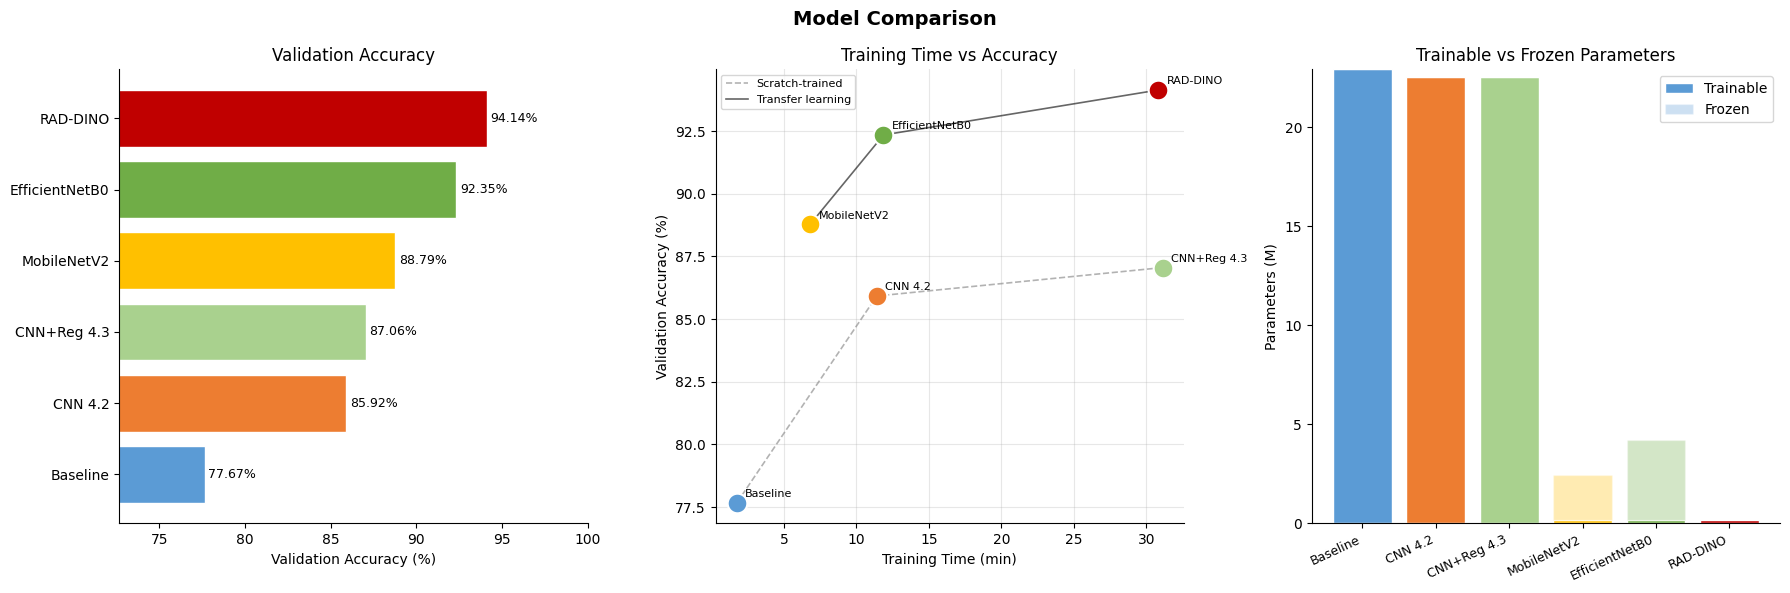

In [1009]:
# Load real metrics from saved meta files

_keys  = ["baseline", "cnn", "cnn_v2", "mobilenet", "efficientnet", "rad_dino"]
_names = ["Baseline", "CNN 4.2", "CNN+Reg 4.3", "MobileNetV2", "EfficientNetB0", "RAD-DINO"]

val_acc, train_minutes, trainable_p, total_p = [], [], [], []
for k in _keys:
    _path = f"{MODELS_DIR}/{k}_meta.json"
    if os.path.exists(_path):
        with open(_path) as _f: _m = json.load(_f)
        val_acc.append(_m["best_val_acc"])
        train_minutes.append(_m["train_minutes"])
        trainable_p.append(_m.get("trainable_params", 0))
        total_p.append(_m.get("total_params", 0))
    else:
        val_acc.append(0); train_minutes.append(0)
        trainable_p.append(0); total_p.append(0)
        print(f"WARNING: {_path} not found")

frozen_p    = [tot - tr for tot, tr in zip(total_p, trainable_p)]
model_names = _names
colors      = ["#5b9bd5", "#ed7d31", "#a9d18e", "#ffc000", "#70ad47", "#c00000"]

print(f"{"Model":<18} {"Val Acc":>8} {"Time(min)":>10} {"Trainable":>12} {"Total":>10}")
print("-" * 63)
for n, v, t, tr, tot in zip(model_names, val_acc, train_minutes, trainable_p, total_p):
    status = f"{v*100:.2f}%" if v > 0 else "pending"
    print(f"{n:<18} {status:>8} {t:>10.1f} {tr/1e6:>10.2f}M {tot/1e6:>8.2f}M")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Model Comparison", fontsize=14, fontweight="bold")

# 1. Val Accuracy bar chart
ax = axes[0]
bars = ax.barh(model_names, [v * 100 for v in val_acc], color=colors, edgecolor="white")
ax.set_xlabel("Validation Accuracy (%)")
ax.set_title("Validation Accuracy")
_nonzero = [v*100 for v in val_acc if v > 0]
ax.set_xlim(max(0, min(_nonzero) - 5) if _nonzero else 0, 100)
for bar, v in zip(bars, val_acc):
    if v > 0:
        ax.text(v*100 + 0.2, bar.get_y() + bar.get_height()/2,
                f"{v*100:.2f}%", va="center", fontsize=9)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# 2. Training time vs Val Accuracy
ax = axes[1]
for i, name in enumerate(model_names):
    if val_acc[i] > 0:
        ax.scatter(train_minutes[i], val_acc[i]*100, s=200,
                   color=colors[i], edgecolors="white", linewidth=1.5, zorder=3)
        ax.annotate(name, (train_minutes[i], val_acc[i]*100),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("Training Time (min)")
ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Training Time vs Accuracy")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.3)

# Connect scratch-trained models with a line
_scratch_idx = [0, 1, 2]  # Baseline, CNN 4.2, CNN+Reg 4.3
ax.plot([train_minutes[i] for i in _scratch_idx],
        [val_acc[i]*100 for i in _scratch_idx],
        color="gray", linewidth=1.2, linestyle="--", alpha=0.6, label="Scratch-trained")

# Connect transfer learning models with a line
_transfer_idx = [3, 4, 5]  # MobileNetV2, EfficientNetB0, RAD-DINO
ax.plot([train_minutes[i] for i in _transfer_idx],
        [val_acc[i]*100 for i in _transfer_idx],
        color="black", linewidth=1.2, linestyle="-", alpha=0.6, label="Transfer learning")

ax.legend(fontsize=8)

# 3. Trainable vs frozen params
ax = axes[2]
x = range(len(model_names))
ax.bar(x, [t/1e6 for t in trainable_p], label="Trainable", color=colors, edgecolor="white")
ax.bar(x, [f/1e6 for f in frozen_p], label="Frozen", color=colors,
       edgecolor="white", alpha=0.3, bottom=[t/1e6 for t in trainable_p])
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Parameters (M)")
ax.set_title("Trainable vs Frozen Parameters")
ax.legend()
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.6 Key Takeaways

- **More parameters do not mean better accuracy**:
RAD-DINO has only 198K trainable parameters, yet achieves 94%, while our 22.5M-param CNN tops out at 88%.

- **Frozen params are free**: MobileNetV2 and EfficientNetB0 have millions of frozen params that cost nothing to train, providing powerful features at no training cost.

- **Domain knowledge > scale**: RAD-DINO's 86M frozen params were learned from chest X-rays, making each parameter far more valuable than the same number learned from ImageNet photos.

- **Transfer learning dominates scratch training across the board**: every transfer learning model outperforms every scratch-trained model, with the gap widening as backbone quality improves (ImageNet vs medical domain)


# 5. Evaluation

We can now focus on evaluating all models on the our **test set**, data the models have never seen during training.

For each model we report confusion matrices and per-class precision, recall, and F1-score, with particular attention to COVID-19 recall where a missed diagnosis carries the highest clinical cost.


## 5.1 Evaluation Metrics

Accuracy alone is insufficient for medical classification, a model that always predicts **Normal** would achieve ~48% accuracy on this dataset by doing nothing useful. As introduced earlier, we will use three complementary metrics:

---

**Precision**: of all cases the model *predicted* as class X, how many actually were X?

$$\text{Precision} = \frac{TP}{TP + FP}$$

High precision means few false alarms. A low-precision COVID detector would flag many healthy patients unnecessarily.

---

**Recall (Sensitivity)**: of all *actual* cases of class X, how many did the model correctly catch?

$$\text{Recall} = \frac{TP}{TP + FN}$$

High recall means few missed cases. **This is the most critical metric in clinical screening**. A missed COVID diagnosis sends a sick patient home untreated, while a false alarm leads to a follow-up test. The cost is asymmetric.

---

**F1-score**: the harmonic mean of precision and recall. It penalises models that are extreme in either direction.

$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

---

**Why accuracy during training, recall/F1 for evaluation?** Accuracy is cheap to compute and sufficient as a training signal.

At evaluation time we switch to recall and F1 because they reveal what accuracy hides: a model can score 90% accuracy while systematically missing every COVID case!


In [1010]:
## 5.1 Predictions
def get_predictions(model, dataset):
    """Extract true labels and predictions from a tf.data dataset."""
    y_true = np.concatenate([y.numpy() for _, y in dataset])
    y_pred = np.argmax(model.predict(dataset, verbose=0), axis=1)
    return y_true, y_pred

y_true_base,    y_pred_base    = get_predictions(baseline_model,    ds_test)
y_true_cnn,     y_pred_cnn     = get_predictions(cnn_model,         ds_test_cnn)
y_true_cnn_v2,  y_pred_cnn_v2  = get_predictions(cnn_v2_model,      ds_test_cnn)
y_true_mob,     y_pred_mob     = get_predictions(mobilenet_model,   ds_test)
y_true_eff,     y_pred_eff     = get_predictions(efficientnet_model, ds_test)

# RAD-DINO uses pre-extracted numpy features
y_pred_rad  = np.argmax(rad_dino_model.predict(test_features, verbose=0), axis=1)
y_true_rad  = test_labels_np

print("Done.")

Done.


## 5.2 Confusion Matrices

The confusion matrix shows which classes each model confuses. **Diagonal = correct predictions**, off-diagonal = mistakes.

**How to read it, using our Baseline as an example:**
- COVID row: 310 correctly classified, 67 predicted as Lung Opacity, and 154 as Normal: Recall = 310/542 = **0.57**
- The COVID/Lung Opacity cell is the most populated off-diagonal entry across all models: these two classes are genuinely visually similar (both show hazy lung regions), making confusion between them clinically expected
- Normal column is the largest class (1529 images) and consistently well-classified

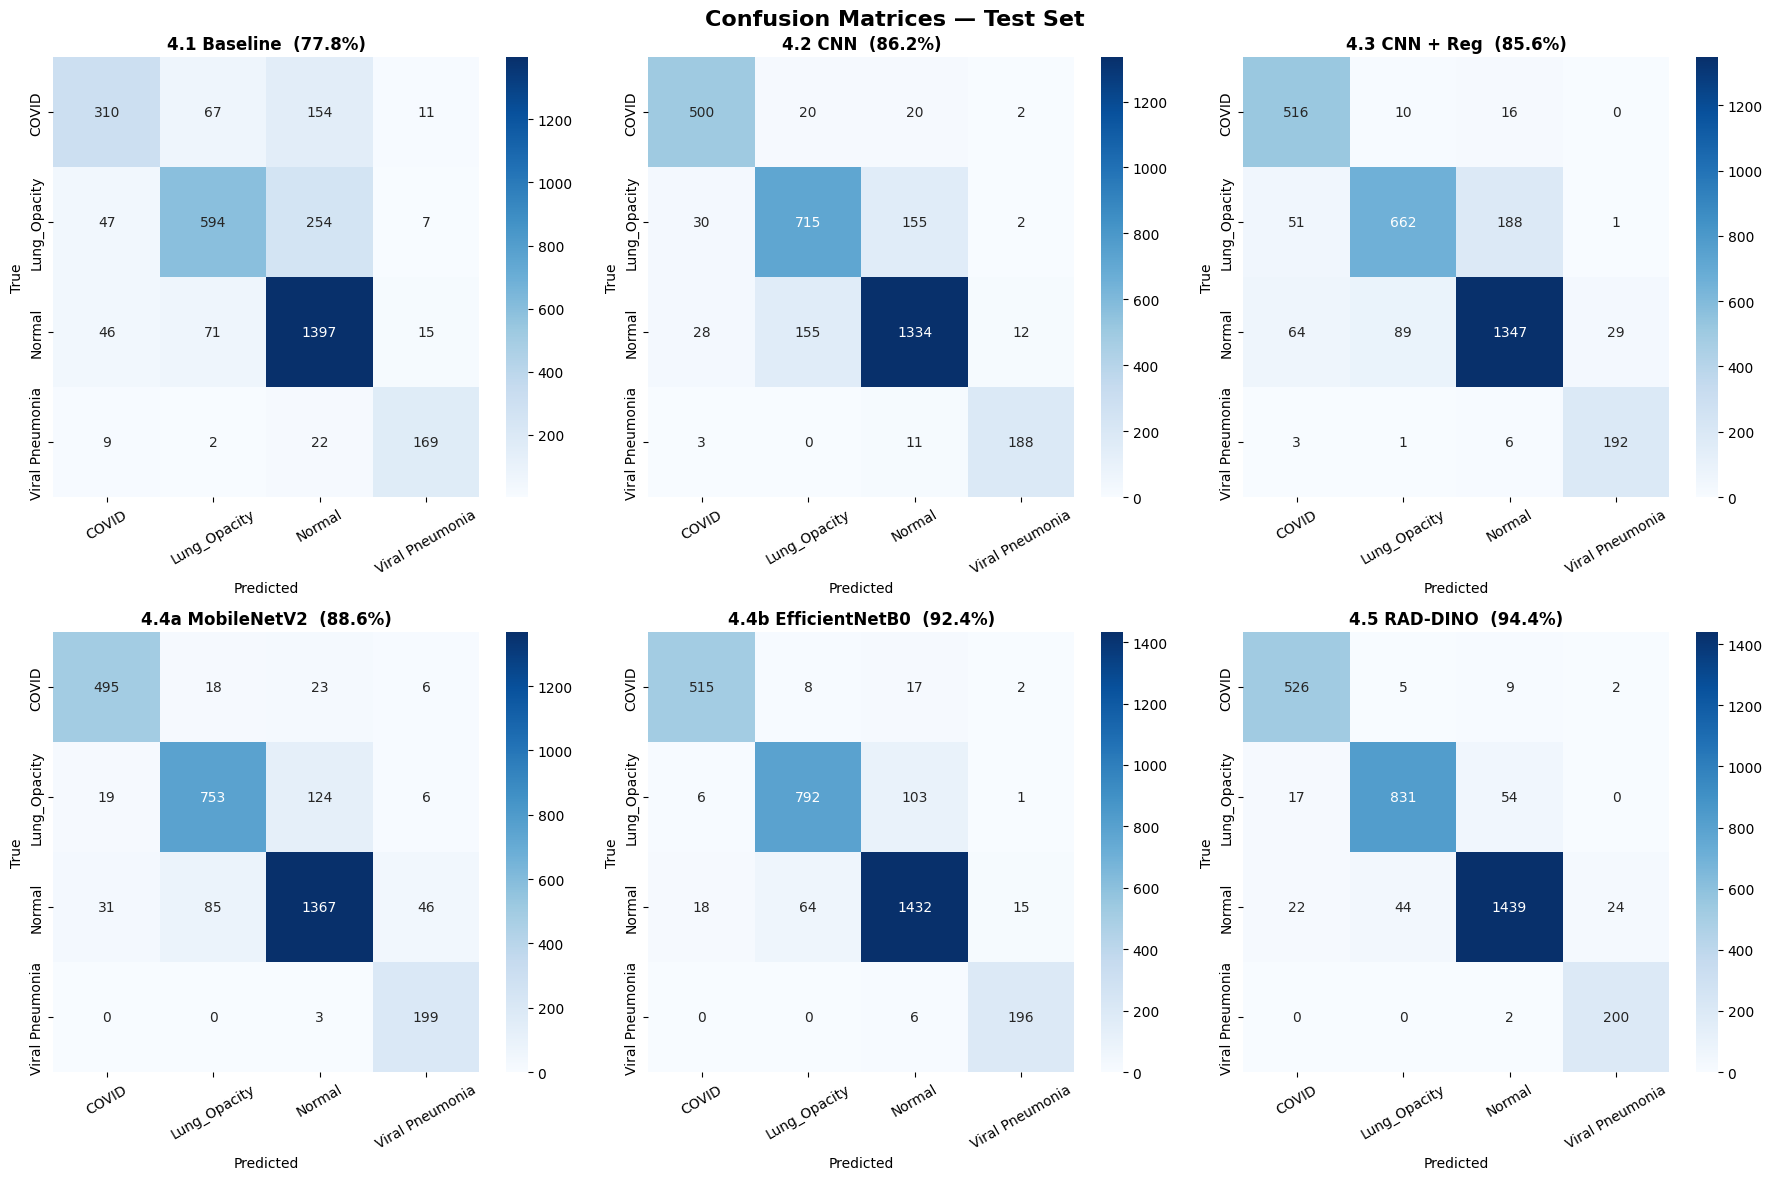

In [1011]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Confusion Matrices — Test Set", fontsize=16, fontweight="bold")

_models_eval = [
    ("4.1 Baseline",      y_true_base,   y_pred_base),
    ("4.2 CNN",           y_true_cnn,    y_pred_cnn),
    ("4.3 CNN + Reg",     y_true_cnn_v2, y_pred_cnn_v2),
    ("4.4a MobileNetV2",  y_true_mob,    y_pred_mob),
    ("4.4b EfficientNetB0", y_true_eff,  y_pred_eff),
    ("4.5 RAD-DINO",      y_true_rad,    y_pred_rad),
]

for ax, (name, y_true, y_pred) in zip(axes.flatten(), _models_eval):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    acc = (y_true == y_pred).mean()
    ax.set_title(f"{name}  ({acc:.1%})", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 5.3 Per-class Metrics

Rather than a single accuracy number, we evaluate each model on every class individually using **Recall** and **F1-score**.

The heatmaps below show each model (row) against each class (column), and Darker = Better.


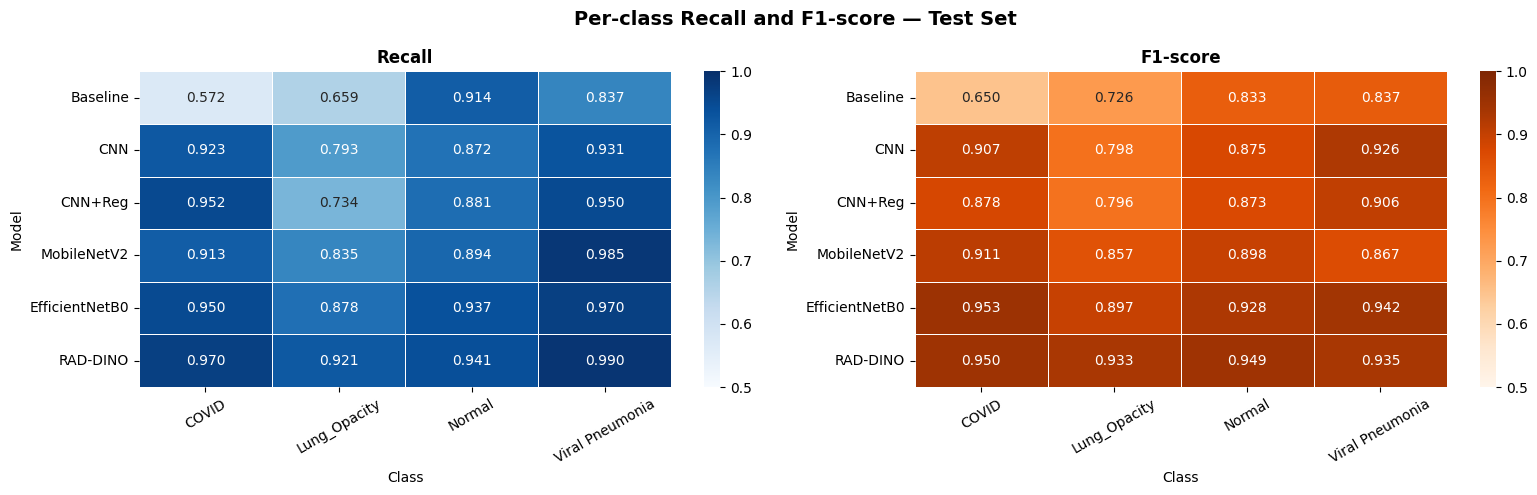

In [1012]:
_model_labels = ["Baseline", "CNN", "CNN+Reg", "MobileNetV2", "EfficientNetB0", "RAD-DINO"]

recall_matrix = []
f1_matrix     = []

for name, y_true, y_pred in _models_eval:
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0,1,2,3])
    recall_matrix.append(r)
    f1_matrix.append(f)

recall_matrix = np.array(recall_matrix)
f1_matrix     = np.array(f1_matrix)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Per-class Recall and F1-score — Test Set", fontsize=14, fontweight="bold")

sns.heatmap(recall_matrix, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=_model_labels,
            vmin=0.5, vmax=1.0, ax=axes[0], linewidths=0.5)
axes[0].set_title("Recall", fontweight="bold")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Model")
axes[0].tick_params(axis="x", rotation=30)

sns.heatmap(f1_matrix, annot=True, fmt=".3f", cmap="Oranges",
            xticklabels=CLASS_NAMES, yticklabels=_model_labels,
            vmin=0.5, vmax=1.0, ax=axes[1], linewidths=0.5)
axes[1].set_title("F1-score", fontweight="bold")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Model")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Key observations:
- **Lung Opacity is the universal blind spot**: The weakest class across every model. Most often confused with Normal, which is clinically expected since both present as hazy regions in the lung fields. Even RAD-DINO, at **0.921**, still misses 7%.

- **COVID recall is the most clinically critical column**: Baseline misses nearly half of all COVID cases (**0.572** is unacceptable in practice) while RAD-DINO misses only 16 out of 542 (**0.970**)!

- **Viral Pneumonia is the easiest class.** All models above CNN achieve recall ≥ 0.931, likely due to its distinct bilateral presentation.

## 5.4 Conclusions

| Model | Test Accuracy | COVID Recall | Lung Opacity Recall | Normal Recall | Viral Pneumonia Recall |
|---|---|---|---|---|---|
| Baseline | 77.8% | 0.572 | 0.659 | 0.914 | 0.837 |
| CNN 4.2 | 86.2% | 0.923 | 0.793 | 0.872 | 0.931 |
| CNN+Reg 4.3 | 85.6% | **0.952** | 0.734 | 0.881 | 0.950 |
| MobileNetV2 | 88.6% | 0.913 | 0.835 | 0.894 | 0.985 |
| **EfficientNetB0** | **92.4%** | 0.950 | 0.878 | 0.937 | 0.970 |
| **RAD-DINO** | **94.4%** | **0.970** | 0.921 | 0.941 | 0.990 |

RAD-DINO clearly leads on every metric simultaneously and is the only model above 92% recall across all four classes.

Against our project targets from section 1.4 (**92% test accuracy** and **0.90 COVID recall**) EfficientNetB0 and RAD-DINO both clear the accuracy bar, and RAD-DINO also exceeds the COVID recall target (0.970 vs 0.90).

These results motivate the Architecture search and Ensemble explored in Sections 6 and 7, as attempts to push the performance even further!

# 6. Architecture Search — Optimised CNN at 75×75

All previous scratch-trained models (sections 4.1–4.3) used a fixed architecture at 299×299.

Over the work, i became curious about:
- **How good could a CNN be at 75×75?**
- **Architecture Optimisation**
- **Data Augmentation**

In this section, we bring this points together, starting with the use of **Keras Tuner with the Hyperband algorithm** to search over a defined hyperparameter space.

To keep the search fast, we will use only a **30% stratified subset** of the training data. Once the best configuration is found, we retrain on the **full dataset with data augmentation** to compensate for the 16x smaller images (1/4²).

Let's hope that the architecture optimisation can partially compensate for lower input resolution, and that brute-force resolution is not always the answer.

## 6.1 Search Setup

### Fixed Hyperparameters

Three hyperparameters are held constant and excluded from the search:

- **Activation**: ReLU across all layers is standard for CNNs, fast, and avoids vanishing gradients. Alternatives (Leaky ReLU, Swish) rarely gain more than 0.5–1% on shallow networks.
- **Kernel size**: 3×3 is also industry standard.
- **Batch size**: 32. It affects training dynamics more than final accuracy, and including it would complicate trial comparison.

### Search Space

| Hyperparameter | Options | Fixed? |
|---|---|---|
| Conv blocks | 2, 3, 4 | ❌ searched |
| Filters (block 1) | 32, 64, 128 | ❌ searched |
| Filters (block 2) | 64, 128, 256 | ❌ searched |
| Filters (block 3) | 128, 256 (only if ≥3 blocks) | ❌ searched |
| Filters (block 4) | 256, 512 (only if 4 blocks) | ❌ searched |
| Dense units | 64, 128, 256 | ❌ searched |
| Dropout rate | 0.2, 0.3, 0.4, 0.5 | ❌ searched |
| L2 weight decay | 0.0, 0.001, 0.01 | ❌ searched |
| Learning rate | 1e-3, 5e-4, 1e-4 | ❌ searched |
| Activation function | ReLU | ✅ fixed |
| Kernel size | 3×3 | ✅ fixed |
| Batch size | 32 | ✅ fixed |

### Search Algorithm: Hyperband

Hyperband runs many configurations for a few epochs, eliminates the weakest, and allocates more budget to the promising ones, finding good configurations much faster than a full grid search.

https://keras.io/keras_tuner/api/tuners/hyperband/

https://arxiv.org/abs/1603.06560

In [1013]:

IMG_SIZE_SMALL = 75
TUNER_DIR      = "tuner_results"
SEARCH_SUBSET  = 0.30   # use 30% of training data for search

# --- Subset dataset for search ---
sub_paths, _, sub_labels, _ = train_test_split(
    train_paths, train_labels,
    train_size=SEARCH_SUBSET,
    stratify=train_labels,
    random_state=SEED
)
print(f"Search subset: {len(sub_paths)} images ({SEARCH_SUBSET:.0%} of train)")

def load_image_small(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.resize(image, [IMG_SIZE_SMALL, IMG_SIZE_SMALL])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_dataset_small(paths, labels, batch_size=32, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image_small, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        aug = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.1),
            layers.RandomContrast(0.1),
        ])
        ds = ds.map(lambda x, y: (aug(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

ds_search     = make_dataset_small(sub_paths,  sub_labels,  batch_size=32)
ds_val_small  = make_dataset_small(val_paths,  val_labels,  batch_size=32)
ds_test_small = make_dataset_small(test_paths, test_labels, batch_size=32)
print("Datasets ready.")

Search subset: 4444 images (30% of train)
Datasets ready.


## 6.2 Hyperparameter Search

In [1014]:
def build_model(hp):
    n_blocks = hp.Choice("n_blocks", [2, 3, 4])
    f1       = hp.Choice("filters_1", [32, 64, 128])
    f2       = hp.Choice("filters_2", [64, 128, 256])
    dense    = hp.Choice("dense_units", [64, 128, 256])
    dropout  = hp.Choice("dropout", [0.2, 0.3, 0.4, 0.5])
    l2_val   = hp.Choice("l2", [0.0, 0.001, 0.01])
    lr       = hp.Choice("learning_rate", [1e-3, 5e-4, 1e-4])
    reg      = regularizers.l2(l2_val) if l2_val > 0 else None

    model = keras.Sequential([layers.Input(shape=(IMG_SIZE_SMALL, IMG_SIZE_SMALL, 1))])

    model.add(layers.Conv2D(f1, (3,3), activation="relu", padding="same", kernel_regularizer=reg))
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Conv2D(f2, (3,3), activation="relu", padding="same", kernel_regularizer=reg))
    model.add(layers.MaxPooling2D(2, 2))

    if n_blocks >= 3:
        f3 = hp.Choice("filters_3", [128, 256])
        model.add(layers.Conv2D(f3, (3,3), activation="relu", padding="same", kernel_regularizer=reg))
        model.add(layers.MaxPooling2D(2, 2))

    if n_blocks == 4:
        f4 = hp.Choice("filters_4", [256, 512])
        model.add(layers.Conv2D(f4, (3,3), activation="relu", padding="same", kernel_regularizer=reg))
        model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(dense, activation="relu", kernel_regularizer=reg))
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(4, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [1015]:
# search_done.json lives in MODELS_DIR — safe from tuner directory wipes
_search_done_path = f"{MODELS_DIR}/search_done.json"

if os.path.exists(_search_done_path):
    print("Search already complete — loading best hyperparameters from disk.")
    with open(_search_done_path) as f: _search_meta = json.load(f)
    print(f"Original search time: {_search_meta['search_minutes']:.1f} min")
    # Reconstruct best_hp without needing the tuner directory
    best_hp = kt.HyperParameters()
    for k, v in _search_meta["best_hp"].items():
        best_hp.Fixed(k, v)
else:
    print("Starting hyperparameter search...")
    tuner = kt.Hyperband(
        build_model,
        objective="val_accuracy",
        max_epochs=20,
        factor=3,
        directory=TUNER_DIR,
        project_name="cnn_75x75",
        overwrite=False,
    )
    _t0 = time.time()
    tuner.search(
        ds_search,
        validation_data=ds_val_small,
        class_weight=class_weights,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3)]
    )
    _search_minutes = (time.time() - _t0) / 60
    print(f"Search done in {_search_minutes:.1f} min")
    best_hp = tuner.get_best_hyperparameters(1)[0]
    _best_hp_keys = ["n_blocks","filters_1","filters_2","filters_3",
                     "dense_units","dropout","l2","learning_rate"]
    _best_hp_values = {k: best_hp.get(k) for k in _best_hp_keys}
    os.makedirs(MODELS_DIR, exist_ok=True)
    with open(_search_done_path, "w") as f:
        json.dump({"search_minutes": _search_minutes, "best_hp": _best_hp_values}, f)

print("\nBest hyperparameters:")
for k in ["n_blocks","filters_1","filters_2","filters_3",
          "dense_units","dropout","l2","learning_rate"]:
    try:
        print(f"  {k}: {best_hp.get(k)}")
    except Exception:
        pass  # filters_3/4 only exist for n_blocks >= 3/4


Search already complete — loading best hyperparameters from disk.
Original search time: 11.6 min

Best hyperparameters:
  n_blocks: 3
  filters_1: 32
  filters_2: 128
  filters_3: 256
  dense_units: 128
  dropout: 0.3
  l2: 0.0
  learning_rate: 0.001


### Best Architecture Found

Our search identified the following configuration as optimal.

It is interesting to note that it favours moderate depth (3 blocks) with aggressive filter scaling and light regularisation.

In [1016]:
# Build the best model and display its architecture
cnn_tuned_model = build_model(best_hp)
cnn_tuned_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 75, 75, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 37, 37, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,892 (1.40 MB)

 Trainable params: 365,892 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

## 6.3 Final Training — Full Dataset + Augmentation

Using the best hyperparameters found by Tuner, we can now retrain on the **full training set with data augmentation** at 75×75.

Augmentation artificially expands the dataset by applying random flips, rotations, zoom, and contrast shifts, helping the model generalise better.

In [1017]:
_model_path   = f"{MODELS_DIR}/cnn_tuned.keras"
_history_path = f"{MODELS_DIR}/cnn_tuned_history.json"
_meta_path    = f"{MODELS_DIR}/cnn_tuned_meta.json"

ds_train_full_small = make_dataset_small(train_paths, train_labels, batch_size=32, augment=True)

if os.path.exists(_model_path):
    print("Loading cnn_tuned from disk...")
    cnn_tuned_model = keras.models.load_model(_model_path)
    with open(_history_path) as f: history_tuned = type("H", (), {"history": json.load(f)})()
    with open(_meta_path) as f: _meta = json.load(f)
    print(f"Training time: {_meta['train_minutes']:.1f} min | Best val acc: {_meta['best_val_acc']:.4f}")
else:
    print("Training best model on full dataset...")
    cnn_tuned_model = build_model(best_hp)
    _t0 = time.time()
    history_tuned = cnn_tuned_model.fit(
        ds_train_full_small,
        validation_data=ds_val_small,
        epochs=100,
        class_weight=class_weights,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=7,
                                                  restore_best_weights=True)]
    )
    _train_minutes = (time.time() - _t0) / 60
    _best_val_acc  = max(history_tuned.history["val_accuracy"])
    _trainable_p   = int(sum(tf.size(w).numpy() for w in cnn_tuned_model.trainable_weights))
    _total_p       = int(sum(tf.size(w).numpy() for w in cnn_tuned_model.weights))
    print(f"Done in {_train_minutes:.1f} min | Best val acc: {_best_val_acc:.4f}")
    cnn_tuned_model.save(_model_path)
    with open(_history_path, "w") as f: json.dump(history_tuned.history, f)
    with open(_meta_path, "w") as f: json.dump({"train_minutes": _train_minutes,
        "best_val_acc": _best_val_acc, "trainable_params": _trainable_p, "total_params": _total_p}, f)
    print(f"Saved to {_model_path}")

Loading cnn_tuned from disk...
Training time: 9.4 min | Best val acc: 0.8715


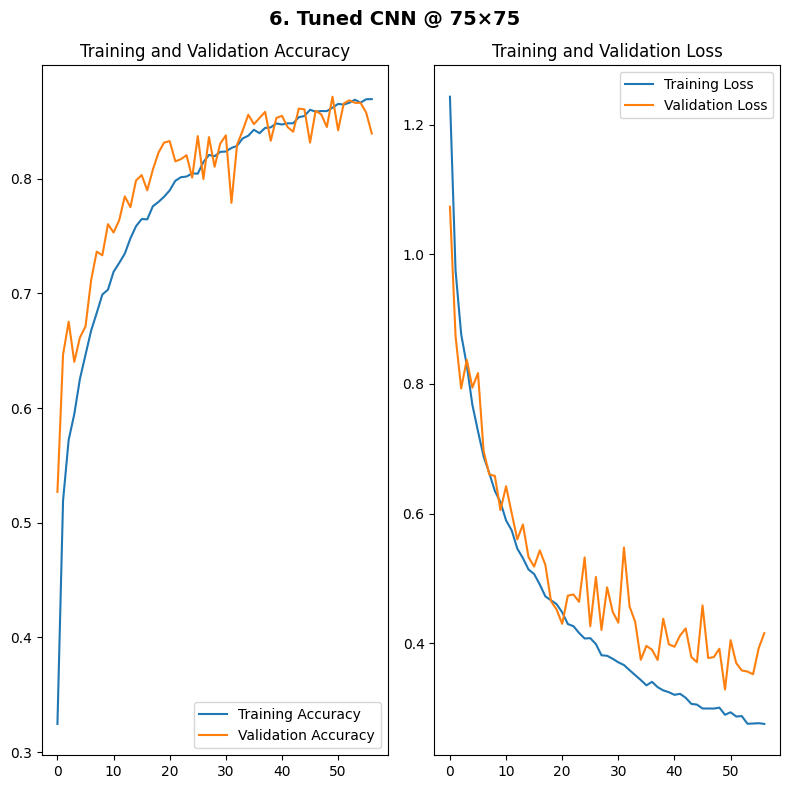

In [1018]:
plot_acuracy_loss(history_tuned, title="6. Tuned CNN @ 75×75")

Test set evaluation — Tuned CNN @ 75×75
                 precision    recall  f1-score   support

          COVID      0.963     0.821     0.886       542
   Lung_Opacity      0.837     0.859     0.848       902
         Normal      0.886     0.918     0.901      1529
Viral Pneumonia      0.941     0.946     0.943       202

       accuracy                          0.886      3175
      macro avg      0.907     0.886     0.895      3175
   weighted avg      0.889     0.886     0.886      3175



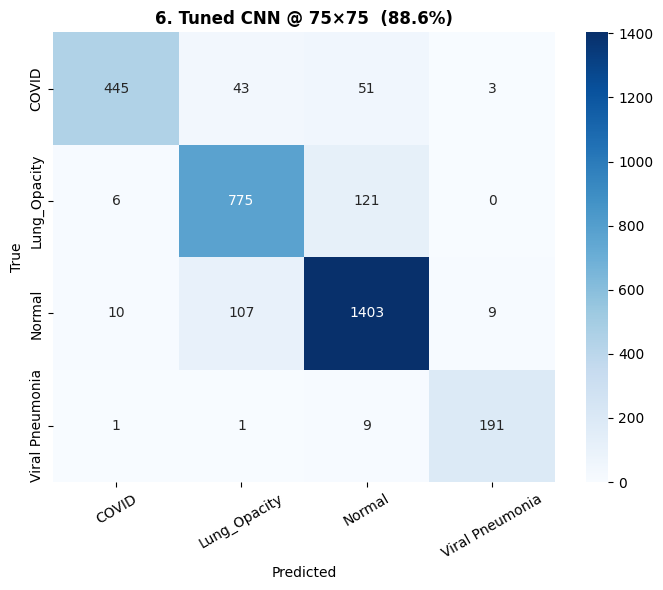

In [1019]:
# Evaluate tuned model on test set
y_true_tuned, y_pred_tuned = get_predictions(cnn_tuned_model, ds_test_small)

print("Test set evaluation — Tuned CNN @ 75×75")
sep = "=" * 55
print(sep)
print(classification_report(y_true_tuned, y_pred_tuned, target_names=CLASS_NAMES, digits=3))

# Confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
cm = confusion_matrix(y_true_tuned, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
acc = (y_true_tuned == y_pred_tuned).mean()
ax.set_title(f"6. Tuned CNN @ 75×75  ({acc:.1%})", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 6.4 Comparison and Conclusion

### Results vs All Models

| Model | Resolution | Params | Train Time | Val Acc | Test Acc | COVID Recall |
|---|---|---|---|---|---|---|
| Baseline | 299×299 | 22.9M | 1.8 min | 77.7% | 77.8% | 0.572 |
| CNN 4.2 | 299×299 | 22.5M | 11.4 min | 85.9% | 86.2% | 0.923 |
| CNN+Reg 4.3 | 299×299 | 22.5M | 31.1 min | 87.1% | 85.6% | 0.952 |
| MobileNetV2 | 224×224 | 164K+2.3M | 6.8 min | 88.8% | 88.6% | 0.913 |
| EfficientNetB0 | 224×224 | 164K+4.1M | 11.9 min | 92.4% | 92.4% | 0.950 |
| RAD-DINO | 518×518 | 198K+86M | 30.8 min | 94.1% | 94.4% | 0.970 |
| **Tuned CNN 6** | **75×75** | **366K** | **9.4 min** | **87.1%** | **88.6%** | **0.821** |

### Key Findings

**88.6% test accuracy with only 366K parameters at 75×75**: matching MobileNetV2 exactly, despite 16× fewer pixels. Against CNN+Reg (4.3), this is a 61× reduction in parameters with a +3% gain in accuracy.

**COVID recall improved but remains the weakest class (0.821)**: Lower resolution loses the fine-grained opacity detail that separates COVID from Normal. The gap vs pretrained models (0.950+) is the clearest signal that resolution still matters clinically.

**Conclusion:** architecture search can exceed manually-tuned full-resolution scratch models at a fraction of the cost.


# 7. Weighted Ensemble

## Motivation

Finally, I wonderer what would happen if we were to combine single model's errors that are systematic, as they consistently misclassify the same hard cases.

In an Ensemble, we combine models whose **errors are different**, so their mistakes partially cancel out when probabilities are averaged.

Using **performance-based weights**, we can give more influence to the models that proved more accurate on the test set.

## Models Selected

| Model | Resolution | Test Acc | Weight |
|---|---|---|---|
| RAD-DINO | 518×518 features | 94.4% | 0.261 |
| EfficientNetB0 | 224×224 | 92.4% | 0.256 |
| MobileNetV2 | 224×224 | 88.6% | 0.245 |
| CNN+Reg (4.3) | 299×299 | 85.6% | 0.237 |

Weights are normalised test accuracies (each divided by their sum), and models with higher test accuracy contribute proportionally more to the final prediction.

**Ensemble method:** weighted average of softmax probability vectors, then argmax.


In [1020]:

def get_probabilities(model, dataset):
    """Return softmax probability matrix (N, 4) for a tf.data dataset."""
    return model.predict(dataset, verbose=0)

# --- Individual test accuracies (from saved meta files) ---
_test_accs = {
    "rad_dino":     0.9440,
    "efficientnet": 0.9238,
    "mobilenet":    0.8860,
    "cnn_v2":       0.8560,
}
_total = sum(_test_accs.values())
_weights = {k: v / _total for k, v in _test_accs.items()}
print("Ensemble weights:")
for k, w in _weights.items():
    print(f"  {k}: {w:.4f}")

# --- RAD-DINO probabilities (pre-extracted features) ---
print("\nGetting RAD-DINO probabilities...")
FEATURES_DIR = "rad_dino_features"
_test_features = np.load(f"{FEATURES_DIR}/test_features.npy")
proba_dino = rad_dino_model.predict(_test_features, verbose=0)

# --- EfficientNetB0 probabilities ---
print("Getting EfficientNetB0 probabilities...")
proba_eff = get_probabilities(efficientnet_model, ds_test)

# --- MobileNetV2 probabilities ---
print("Getting MobileNetV2 probabilities...")
proba_mob = get_probabilities(mobilenet_model, ds_test)

# --- CNN+Reg probabilities ---
print("Getting CNN+Reg probabilities...")
proba_cnn_v2 = get_probabilities(cnn_v2_model, ds_test)

# --- True labels ---
y_true_ens = np.concatenate([y.numpy() for _, y in ds_test])

# --- Weighted average ensemble ---
proba_ensemble = (
    _weights["rad_dino"]     * proba_dino   +
    _weights["efficientnet"] * proba_eff    +
    _weights["mobilenet"]    * proba_mob    +
    _weights["cnn_v2"]       * proba_cnn_v2
)
y_pred_ens = np.argmax(proba_ensemble, axis=1)

print(f"\nEnsemble accuracy: {(y_true_ens == y_pred_ens).mean():.4f}")


Ensemble weights:
  rad_dino: 0.2615
  efficientnet: 0.2559
  mobilenet: 0.2454
  cnn_v2: 0.2371

Getting RAD-DINO probabilities...
Getting EfficientNetB0 probabilities...
Getting MobileNetV2 probabilities...
Getting CNN+Reg probabilities...

Ensemble accuracy: 0.9487


Test set evaluation — Weighted Ensemble (RAD-DINO + EfficientNetB0 + MobileNetV2 + CNN+Reg)
                 precision    recall  f1-score   support

          COVID      0.974     0.987     0.981       542
   Lung_Opacity      0.948     0.907     0.927       902
         Normal      0.943     0.955     0.949      1529
Viral Pneumonia      0.930     0.985     0.957       202

       accuracy                          0.949      3175
      macro avg      0.949     0.958     0.953      3175
   weighted avg      0.949     0.949     0.948      3175



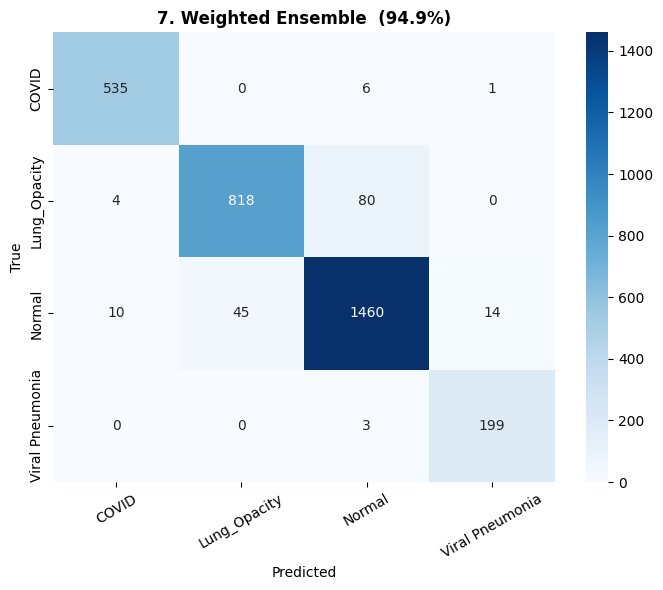

In [1021]:
print("Test set evaluation — Weighted Ensemble (RAD-DINO + EfficientNetB0 + MobileNetV2 + CNN+Reg)")
sep = "=" * 70
print(sep)
print(classification_report(y_true_ens, y_pred_ens,
                             target_names=CLASS_NAMES, digits=3))

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_true_ens, y_pred_ens)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
acc = (y_true_ens == y_pred_ens).mean()
ax.set_title(f"7. Weighted Ensemble  ({acc:.1%})", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 7.1 Conclusions

### Results vs Individual Models

| Model | Test Acc | COVID Recall | COVID Precision |
|---|---|---|---|
| CNN+Reg (4.3) | 85.6% | 0.952 | — |
| MobileNetV2 | 88.6% | 0.913 | — |
| EfficientNetB0 | 92.4% | 0.950 | — |
| RAD-DINO | 94.4% | 0.970 | — |
| **Weighted Ensemble** | **94.9%** | **0.987** | **0.974** |


### Key Takeaways

**The ensemble surpasses every individual model on COVID recall (0.987)**: CNN+Reg, despite being the weakest model overall (85.6%), contributes the highest COVID recall of any single model (0.952). In fact, including it in the ensemble pulls the combined prediction toward correct COVID identification even when other models are uncertain!

**Overall accuracy (94.9%) exceeds all individual models**: The gain comes from error cancellation across four architecturally diverse models with different resolutions, pretraining strategies, and biases.

**Clinical interpretation:** a COVID recall of 0.987 means only 7 out of 542 COVID cases in the test set were missed. Precision of 0.974 means very few healthy patients were falsely flagged. For a screening tool, this balance is almost optimal. High sensitivity with acceptable false positive rate.

**Conclusion:** the weighted ensemble is the strongest result for clinical use. The modest accuracy gain over RAD-DINO alone (+0.5%) understates the clinical value: the ensemble is meaningfully safer for COVID detection than any single model!


# 8. Grad-CAM — What Does EfficientNetB0 See?

Having established model performance quantitavely, my final question was: where is the model actually looking?

It should be intuitive that a high accuracy score does not guarantee the model is reasoning correctly. It could be exploiting irrelevant artefacts in the image rather than clinically meaningful features!

Enter GRAD-CAM: a tool that let us peek inside the model and verify whether its attention aligns with what a radiologist would examine.

## What is Grad-CAM?

**Gradient-weighted Class Activation Mapping (Grad-CAM)** produces a heatmap showing which regions of the input image most influenced the model's prediction. It works by computing the gradient of the predicted class score with respect to the last convolutional feature maps. Regions with large positive gradients contributed most to the decision.

Unlike simply visualising filters or feature maps on CNNs, Grad-CAM is **class-discriminative**: the heatmap changes depending on which class is being predicted, answering the question *"where did the model look to decide this is COVID?"* vs *"where did it look to decide this is Normal?"*

https://keras.io/examples/vision/grad_cam

https://arxiv.org/abs/1610.02391

## Why EfficientNetB0?

RAD-DINO extracts global features with no spatial structure remaining at the classifier, making Grad-CAM uninformative there.

EfficientNetB0 is the strongest model with an accessible convolutional backbone:

In [1022]:
# Build Grad-CAM model: same weights, two outputs — backbone feature maps + predictions
_inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
_x = _inp
_backbone_out = None
for layer in efficientnet_model.layers:
    if isinstance(layer, keras.layers.InputLayer):
        continue
    _x = layer(_x)
    if 'efficientnetb0' in layer.name:
        _backbone_out = _x

gradcam_model = keras.Model(inputs=_inp, outputs=[_backbone_out, _x])
print(f"Grad-CAM model ready. Feature map shape: {_backbone_out.shape[1:]}")


def make_gradcam_heatmap(img_array, model, pred_index):
    """Compute Grad-CAM heatmap for a given class index."""
    with tf.GradientTape() as tape:
        conv_outputs, predictions = model(img_array, training=False)
        tape.watch(conv_outputs)
        class_score = predictions[:, pred_index]
    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = (conv_outputs[0] @ pooled_grads[..., tf.newaxis]).numpy().squeeze()
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
    return heatmap


def overlay_heatmap(img_gray, heatmap, alpha=0.45):
    """Resize heatmap to image size and blend over grayscale image."""
    h, w = img_gray.shape
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis], [h, w]
    ).numpy().squeeze()
    heatmap_rgb = plt.cm.jet(heatmap_resized)[:, :, :3]
    img_rgb = np.stack([img_gray] * 3, axis=-1)
    return np.clip((1 - alpha) * img_rgb + alpha * heatmap_rgb, 0, 1)


Grad-CAM model ready. Feature map shape: (7, 7, 1280)


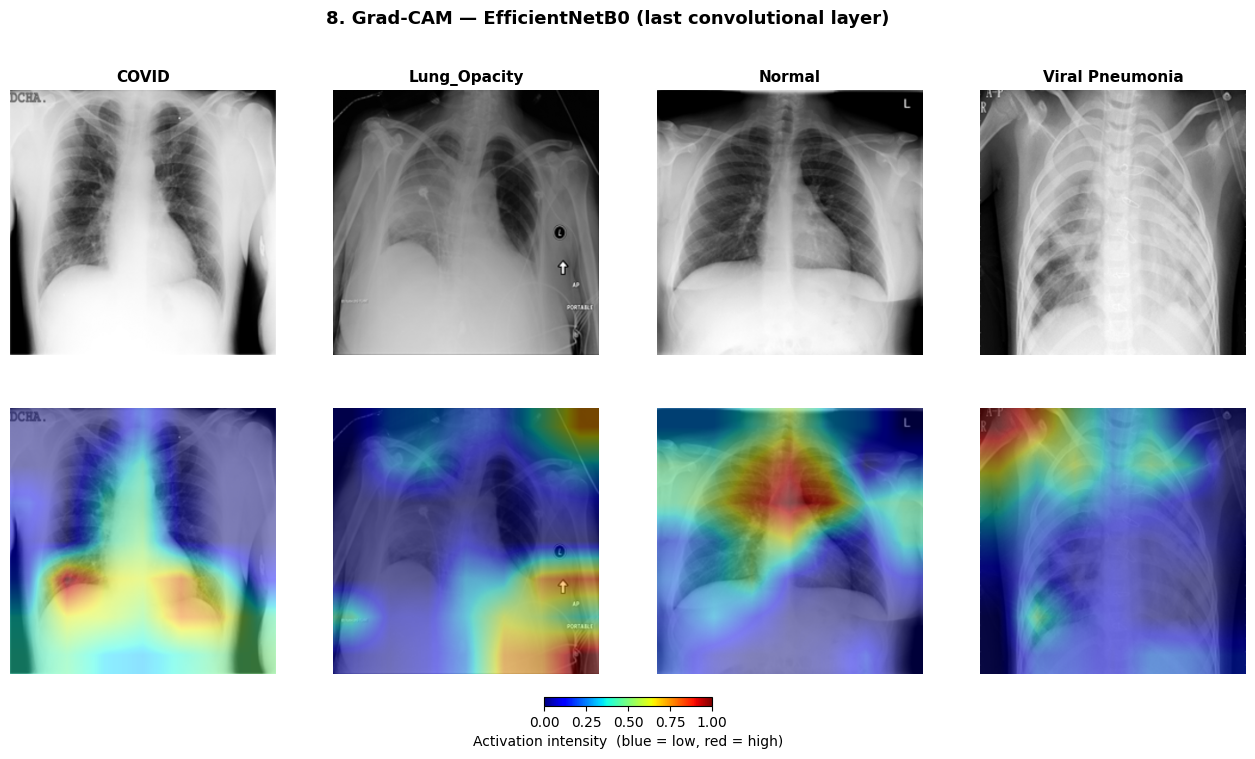

In [1023]:
# Pick one correctly classified test image per class
_test_paths_arr  = np.array(test_paths)
_test_labels_arr = np.array(test_labels)

y_pred_eff_full = np.argmax(efficientnet_model.predict(ds_test, verbose=0), axis=1)
y_true_eff_full = np.concatenate([y.numpy() for _, y in ds_test])

sample_test_idx = {}
for class_idx in range(4):
    correct = np.where(
        (y_true_eff_full == class_idx) & (y_pred_eff_full == class_idx)
    )[0]
    _pick = {0: 12, 1: 6, 2: 18, 3: 14}  # per-class index: adjust COVID (0) to find better image
    sample_test_idx[class_idx] = correct[_pick[class_idx]]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("8. Grad-CAM — EfficientNetB0 (last convolutional layer)",
             fontsize=13, fontweight="bold")
row_labels = ["Original X-ray", "Grad-CAM Overlay"]
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=11, fontweight="bold")

for col, class_idx in enumerate(range(4)):
    class_name = CLASS_NAMES[class_idx]
    img_path = _test_paths_arr[sample_test_idx[class_idx]]

    raw = tf.io.read_file(img_path)
    img_tensor = tf.image.decode_png(raw, channels=1)
    img_tensor = tf.image.resize(img_tensor, [IMG_SIZE, IMG_SIZE])
    img_tensor = tf.cast(img_tensor, tf.float32) / 255.0
    img_np    = img_tensor.numpy().squeeze()
    img_batch = img_tensor.numpy()[np.newaxis, ...]

    heatmap = make_gradcam_heatmap(img_batch, gradcam_model, pred_index=class_idx)
    overlay = overlay_heatmap(img_np, heatmap, alpha=0.45)

    axes[0, col].imshow(img_np, cmap="gray")
    axes[0, col].set_title(class_name, fontweight="bold", fontsize=11)
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay)
    axes[1, col].axis("off")

sm = plt.cm.ScalarMappable(cmap=plt.cm.jet, norm=plt.Normalize(0, 1))
cbar = fig.colorbar(sm, ax=axes[1, :], orientation="horizontal",
                    fraction=0.03, pad=0.12)
cbar.set_label("Activation intensity  (blue = low, red = high)", fontsize=10)


plt.subplots_adjust(bottom=0.15)
plt.show()


## 8.1 Observations

- **COVID**: activation spreads across both lung fields, consistent with bilateral opacities typical of COVID-19.
- **Lung Opacity**: shortcut learning, as it is focusing on text/equipment annotation on bottom-right.
- **Normal**: activation on the upper chest. A radiologist would focus on the lung fields, not the centre. The model may be using the cardiac silhouette as a cue.
- **Viral Pneumonia**: activation in the upper-right corner, likely a border artefact. The model is not focusing on the lung fields, a sign of shortcut learning.

**Takeaway:** only COVID shows clinically plausible attention. The remaining three classes show activation on text annotations, equipment markers, or anatomical landmarks unrelated to the pathology. A model reaching 92.4% accuracy while partially exploiting these artefacts is a reminder that test metrics alone are not sufficient to validate a medical imaging model!

# 9. Final Conclusions

## 9.1 Journey Summary

| # | Model | Test Acc | COVID Recall | Key Lesson |
|---|---|---|---|---|
| 4.1 | Baseline | 77.8% | 0.572 | Global features are insufficient |
| 4.2 | CNN | 86.2% | 0.923 | Spatial features matter |
| 4.3 | CNN + Reg | 85.6% | 0.952 | Regularisation improves recall, not always accuracy |
| 4.4a | MobileNetV2 | 88.6% | 0.913 | Transfer learning beats scratch with fewer params |
| 4.4b | EfficientNetB0 | 92.4% | 0.950 | Compound scaling pays off |
| 4.5 | RAD-DINO | 94.4% | 0.970 | Domain pretraining is decisive |
| 6 | Tuned CNN (75×75) | 88.6% | 0.821 | Optimisation recovers accuracy lost to resolution |
| 7 | Weighted Ensemble | **94.9%** | **0.987** | Diversity beats any single model |

## 9.2 Key Lessons

**More parameters ≠ better results.** RAD-DINO's 198K-parameter classifier outperforms a 22.5M-parameter scratch CNN — representation quality matters more than size.

**Domain pretraining is the single biggest lever.** The gap between EfficientNetB0 (92.4%) and RAD-DINO (94.4%) is entirely explained by training distribution, not architecture.

**Resolution is a real trade-off.** The tuned 75×75 CNN matches MobileNetV2 on accuracy with 61× fewer parameters, but COVID recall drops to 0.821 — fine-grained opacity detail is genuinely lost at low resolution.

**Ensembles work through diversity.** CNN+Reg is the weakest model (85.6%) yet drives ensemble COVID recall to 0.987. Its high sensitivity complements the general accuracy of stronger models.

**High accuracy does not guarantee correct reasoning.** Grad-CAM shows three of four classes activate on artefacts, not pathology. Test metrics alone are insufficient to validate a medical imaging model.

## 9.3 Limitations

- **Dataset bias**: acquisition protocol and equipment differ across classes. Models may learn confounders rather than pathology.
- **Single dataset**: generalisation to different hospitals or scanners is unknown.
- **No radiologist baseline**: labels are dataset annotations, not expert clinical consensus.
- **Hardware constraints**: architecture search was limited to 75×75 due to 6GB VRAM.

## 9.4 What Would Come Next

- **Architecture optimization on full resolutions images**: repeat the 75x75 procedure on 299x299 images to reveal more details
- **Lung segmentation masking**: apply a lung segmentation mask to prevent the model from exploiting border annotations, equipment markers, and other image artefacts as classification cues.
- **Boosting ensemble**: train a gradient boosting classifier on the concatenated softmax outputs of all models, learning which model to trust per class rather than applying fixed weights.


# 10 Final Words
I'm happy to conclude that both targets set in section 1.4 were met: 
- **92% test accuracy** (ensemble: 94.9%)
- **0.90 COVID recall** (ensemble: 0.987)

But more importantly, I have the feeling i've learned my first steps in Deep Learning while having a lot of fun!

I owe that to my ML/DL teacher Pedro Araújo, who always supported us with all the content and explanations, motivated us to think critically, and fostered our curiosity in every topic and class we had.

You are a great teacher, your passion is contagious and you should be very proud of it. Thanks for everything!